Vorgehensweise: 

1. Daten laden
2. Daten überprüfen und bereinigen
3. Berechnungen, Datenanalyse und Visualisierungen für das jeweilige Kapitel



1) Daten laden

In [1]:
# Import der Bibliotheken
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf 

In [2]:
# Datei aus Unterordner laden
df = pd.read_csv("data/data_in_use/diabetes_binary_health_indicators_BRFSS2015.csv")

# Erste 5 Zeilen anzeigen
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0







2) Daten überprüfen und bereinigen


In [3]:
# Anzahl der Datensaätze und Spalten
df.shape

(253680, 22)

In [4]:
# Zeigt Spaltennamen, Anzahl Werte und Datentyp an
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [5]:
# Spaltennamen auf deutsch übersetzen
# Dictionary für die Übersetzung
uebersetzung = {
    "Diabetes_binary": "Diabetes_Status",
    "HighBP": "Bluthochdruck",
    "HighChol": "Cholesterin_hoch",
    "CholCheck": "Cholesterin_Check",
    "BMI": "BMI",
    "Smoker": "Raucher_Status",
    "Stroke": "Schlaganfall",
    "HeartDiseaseorAttack": "Herzerkrankung_Infarkt",
    "PhysActivity": "Sportliche_Aktivitaet",
    "Fruits": "Obst_Konsum",
    "Veggies": "Gemuese_Konsum",
    "HvyAlcoholConsump": "Hoher_Alkoholkonsum",
    "AnyHealthcare": "Krankenversicherung",
    "NoDocbcCost": "Kein_Arzt_wegen_Kosten",
    "GenHlth": "Allgemeine_Gesundheit",
    "MentHlth": "Psychische_Gesundheit",
    "PhysHlth": "Koerperliche_Gesundheit",
    "DiffWalk": "Einschränkung_Gehen",
    "Sex": "Geschlecht",
    "Age": "Altersgruppe",
    "Education": "Bildungsstand",
    "Income": "Einkommensstufe",
    "BMI_Kategorie_Text": "BMI_Kategorie_Text"
}

# Spalten im Dataframe umbenennen
df = df.rename(columns=uebersetzung)

#Check
display(pd.DataFrame(df.columns, columns=["Neue_Spaltennamen"]))

,Neue_Spaltennamen
0,Diabetes_Status
1,Bluthochdruck
2,Cholesterin_hoch
3,Cholesterin_Check
4,BMI
5,Raucher_Status
6,Schlaganfall
7,Herzerkrankung_Infarkt
8,Sportliche_Aktivitaet
9,Obst_Konsum


In [6]:
# Liste der float64 Spalten die in int8 umgewandelt werden sollen
int8_spalten = [
    "Diabetes_Status",
    "Bluthochdruck",
    "Cholesterin_hoch",
    "Cholesterin_Check",
    "BMI",  
    "Raucher_Status",
    "Schlaganfall",
    "Herzerkrankung_Infarkt",
    "Sportliche_Aktivitaet",
    "Obst_Konsum",
    "Gemuese_Konsum",
    "Hoher_Alkoholkonsum",
    "Krankenversicherung",
    "Kein_Arzt_wegen_Kosten",
    "Allgemeine_Gesundheit",
    "Psychische_Gesundheit",
    "Koerperliche_Gesundheit",
    "Einschränkung_Gehen",
    "Geschlecht",
    "Altersgruppe",
    "Bildungsstand",
    "Einkommensstufe"
]

# Alle aufgelisteten Spalten in int8 konvertieren
df[int8_spalten] = df[int8_spalten].astype("int8")

In [7]:
# Spaltennamen, Nan; count, DType
df.info()

# 8-Werte-Übersicht pro Spalte
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   Diabetes_Status          253680 non-null  int8 
 1   Bluthochdruck            253680 non-null  int8 
 2   Cholesterin_hoch         253680 non-null  int8 
 3   Cholesterin_Check        253680 non-null  int8 
 4   BMI                      253680 non-null  int8 
 5   Raucher_Status           253680 non-null  int8 
 6   Schlaganfall             253680 non-null  int8 
 7   Herzerkrankung_Infarkt   253680 non-null  int8 
 8   Sportliche_Aktivitaet    253680 non-null  int8 
 9   Obst_Konsum              253680 non-null  int8 
 10  Gemuese_Konsum           253680 non-null  int8 
 11  Hoher_Alkoholkonsum      253680 non-null  int8 
 12  Krankenversicherung      253680 non-null  int8 
 13  Kein_Arzt_wegen_Kosten   253680 non-null  int8 
 14  Allgemeine_Gesundheit    253680 non-null  int8 

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Krankenversicherung,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [8]:
# Check doppelte Werte 
df.duplicated().sum()

np.int64(24206)

In [9]:
 # Zeigt alle Zeilen an, die im Datensatz mehrfach vorkommen
df_duplicates = df[df.duplicated(keep=False)]
df_duplicates

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Krankenversicherung,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe
5,0,1,1,1,25,1,0,0,1,1,...,1,0,2,0,2,0,1,10,6,8
25,0,0,0,1,32,0,0,0,1,1,...,1,0,2,0,0,0,0,5,6,8
29,0,0,1,1,31,1,0,0,1,1,...,1,0,1,0,0,0,1,12,6,8
44,0,0,1,1,31,1,0,0,0,1,...,1,0,2,0,0,0,0,8,5,8
52,1,1,1,1,27,1,0,0,0,0,...,1,0,5,0,30,1,0,10,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1,1,1,1,33,0,0,0,1,1,...,1,0,3,0,0,0,1,9,6,6
253550,0,0,0,1,25,0,0,0,1,1,...,1,0,1,0,0,0,0,7,6,8
253563,0,0,1,1,24,1,0,0,1,1,...,1,0,2,0,0,0,1,8,6,8
253597,0,0,0,1,24,0,0,0,1,1,...,1,0,2,0,0,0,0,5,6,8


In [10]:
# Gruppiert alle identischen Zeilen (Profile) und zählt wie oft sie vorkommen
haeufigste_profile = df.value_counts()

# Zeigt die Top 5 der am häufigsten vorkommenden Profile
print(haeufigste_profile)

Diabetes_Status  Bluthochdruck  Cholesterin_hoch  Cholesterin_Check  BMI  Raucher_Status  Schlaganfall  Herzerkrankung_Infarkt  Sportliche_Aktivitaet  Obst_Konsum  Gemuese_Konsum  Hoher_Alkoholkonsum  Krankenversicherung  Kein_Arzt_wegen_Kosten  Allgemeine_Gesundheit  Psychische_Gesundheit  Koerperliche_Gesundheit  Einschränkung_Gehen  Geschlecht  Altersgruppe  Bildungsstand  Einkommensstufe
0                0              0                 1                  21   0               0             0                       1                      1            1               0                    1                    0                       1                      0                      0                        0                    0           6             6              8                  59
                                                                     23   0               0             0                       1                      1            1               0                    1  

In [11]:
# Das absolut häufigste Profil ermitteln

# Zählung durchführen und speichern
profil_counts = df.value_counts()
haeufigstes_profil_anzahl = profil_counts.iloc[0]

# Als Tabelle darstellen und hochkant drehen (.T)
df_top_profil = pd.DataFrame([profil_counts.index[0]], columns=df.columns).T
df_top_profil.columns = ["Häufigstes_Profil"]

#Check
print(f"Dieses Profil kommt {haeufigstes_profil_anzahl:,} Mal im Datensatz vor:")
display(df_top_profil)

Dieses Profil kommt 59 Mal im Datensatz vor:


,Häufigstes_Profil
Diabetes_Status,0
Bluthochdruck,0
Cholesterin_hoch,0
Cholesterin_Check,1
BMI,21
Raucher_Status,0
Schlaganfall,0
Herzerkrankung_Infarkt,0
Sportliche_Aktivitaet,1
Obst_Konsum,1


Anmerkung:  
Die gleichen Profile resultieren aus der Art der Befragung. Die Antwortmöglichkeiten sind meist Ja/Nein, so dass es bei einer Gesamtdatenmenge von 253.680 Befragten bzw. Profilen zu Dopplungen kommt. Deshalb wurden die doppelten Datensätze nicht gelöscht.

In [12]:
# Check missing values
df_NaN_True = df.isna() 
df_NaN_True.sum()

Diabetes_Status            0
Bluthochdruck              0
Cholesterin_hoch           0
Cholesterin_Check          0
BMI                        0
Raucher_Status             0
Schlaganfall               0
Herzerkrankung_Infarkt     0
Sportliche_Aktivitaet      0
Obst_Konsum                0
Gemuese_Konsum             0
Hoher_Alkoholkonsum        0
Krankenversicherung        0
Kein_Arzt_wegen_Kosten     0
Allgemeine_Gesundheit      0
Psychische_Gesundheit      0
Koerperliche_Gesundheit    0
Einschränkung_Gehen        0
Geschlecht                 0
Altersgruppe               0
Bildungsstand              0
Einkommensstufe            0
dtype: int64

In [13]:
# Einteilung für BMI-Werte vornehmen
# neue Spalte erstellen und BMI in aktuelle WHO-Klassifikation einordnen

def bmi_kategorie_who(bmi):
    if bmi < 18.5:
        return "Untergewicht (< 18.5)"
    elif bmi < 25.0:
        return "Normalgewicht (18.5 - 24.9)"
    elif bmi < 30.0:
        return "Übergewicht (25.0 - 29.9)"
    elif bmi < 35.0:
        return "Adipositas Grad I (30.0 - 34.9)"
    elif bmi < 40.0:
        return "Adipositas Grad II (35.0 - 39.9)"
    else:
        return "Adipositas Grad III (>= 40.0)"

# Spalte anlegen
df["BMI_Kategorie_Text"] = df["BMI"].apply(bmi_kategorie_who)

# Feste Reihenfolge für die Achsensortierung in Grafiken
reihenfolge_who = [
    "Untergewicht (< 18.5)",
    "Normalgewicht (18.5 - 24.9)",
    "Übergewicht (25.0 - 29.9)",
    "Adipositas Grad I (30.0 - 34.9)",
    "Adipositas Grad II (35.0 - 39.9)",
    "Adipositas Grad III (>= 40.0)"
]

In [14]:
# BMI: numerische Spalte für Heatmap
def bmi_kategorie_code(bmi):
    if bmi < 18.5:
        return 0  # Untergewicht
    elif bmi < 25.0:
        return 1  # Normalgewicht
    elif bmi < 30.0:
        return 2  # Übergewicht
    elif bmi < 35.0:
        return 3  # Adipositas Grad I
    elif bmi < 40.0:
        return 4  # Adipositas Grad II
    else:
        return 5  # Adipositas Grad III

# Neue numerische Spalte 
df["BMI_Kategorie_Code"] = df["BMI"].apply(bmi_kategorie_code)

#Check
display(df[["BMI", "BMI_Kategorie_Text", "BMI_Kategorie_Code"]].head())

,BMI,BMI_Kategorie_Text,BMI_Kategorie_Code
0,40,Adipositas Grad III (>= 40.0),5
1,25,Übergewicht (25.0 - 29.9),2
2,28,Übergewicht (25.0 - 29.9),2
3,27,Übergewicht (25.0 - 29.9),2
4,24,Normalgewicht (18.5 - 24.9),1


Anmerkung:   
Heatmap mit allen numerischen Variablen erstellen. Daraus ergibt sich der Fokus für die Datananylyse.  

In [15]:
# Berechnungen: Korrelations-Heatmap

# Korrelationsmatrix für alle numerischen Spalten berechnen
df_numerisch = df.select_dtypes(include=["number"])
corr_matrix = df_numerisch.corr()

#Check
display(corr_matrix.round(2))

,Diabetes_Status,Bluthochdruck,Cholesterin_hoch,Cholesterin_Check,BMI,Raucher_Status,Schlaganfall,Herzerkrankung_Infarkt,Sportliche_Aktivitaet,Obst_Konsum,...,Kein_Arzt_wegen_Kosten,Allgemeine_Gesundheit,Psychische_Gesundheit,Koerperliche_Gesundheit,Einschränkung_Gehen,Geschlecht,Altersgruppe,Bildungsstand,Einkommensstufe,BMI_Kategorie_Code
Diabetes_Status,1.00,0.26,0.20,0.06,0.22,0.06,0.11,0.18,-0.12,-0.04,...,0.03,0.29,0.07,0.17,0.22,0.03,0.18,-0.12,-0.16,0.23
Bluthochdruck,0.26,1.00,0.30,0.10,0.21,0.10,0.13,0.21,-0.13,-0.04,...,0.02,0.30,0.06,0.16,0.22,0.05,0.34,-0.14,-0.17,0.23
Cholesterin_hoch,0.20,0.30,1.00,0.09,0.11,0.09,0.09,0.18,-0.08,-0.04,...,0.01,0.21,0.06,0.12,0.14,0.03,0.27,-0.07,-0.09,0.12
Cholesterin_Check,0.06,0.10,0.09,1.00,0.03,-0.01,0.02,0.04,0.00,0.02,...,-0.06,0.05,-0.01,0.03,0.04,-0.02,0.09,0.00,0.01,0.04
BMI,0.22,0.21,0.11,0.03,1.00,0.01,0.02,0.05,-0.15,-0.09,...,0.06,0.24,0.09,0.12,0.20,0.04,-0.04,-0.10,-0.10,0.92
Raucher_Status,0.06,0.10,0.09,-0.01,0.01,1.00,0.06,0.11,-0.09,-0.08,...,0.05,0.16,0.09,0.12,0.12,0.09,0.12,-0.16,-0.12,0.02
Schlaganfall,0.11,0.13,0.09,0.02,0.02,0.06,1.00,0.20,-0.07,-0.01,...,0.03,0.18,0.07,0.15,0.18,0.00,0.13,-0.08,-0.13,0.02
Herzerkrankung_Infarkt,0.18,0.21,0.18,0.04,0.05,0.11,0.20,1.00,-0.09,-0.02,...,0.03,0.26,0.06,0.18,0.21,0.09,0.22,-0.10,-0.14,0.06
Sportliche_Aktivitaet,-0.12,-0.13,-0.08,0.00,-0.15,-0.09,-0.07,-0.09,1.00,0.14,...,-0.06,-0.27,-0.13,-0.22,-0.25,0.03,-0.09,0.20,0.20,-0.15
Obst_Konsum,-0.04,-0.04,-0.04,0.02,-0.09,-0.08,-0.01,-0.02,0.14,1.00,...,-0.04,-0.10,-0.07,-0.04,-0.05,-0.09,0.06,0.11,0.08,-0.09


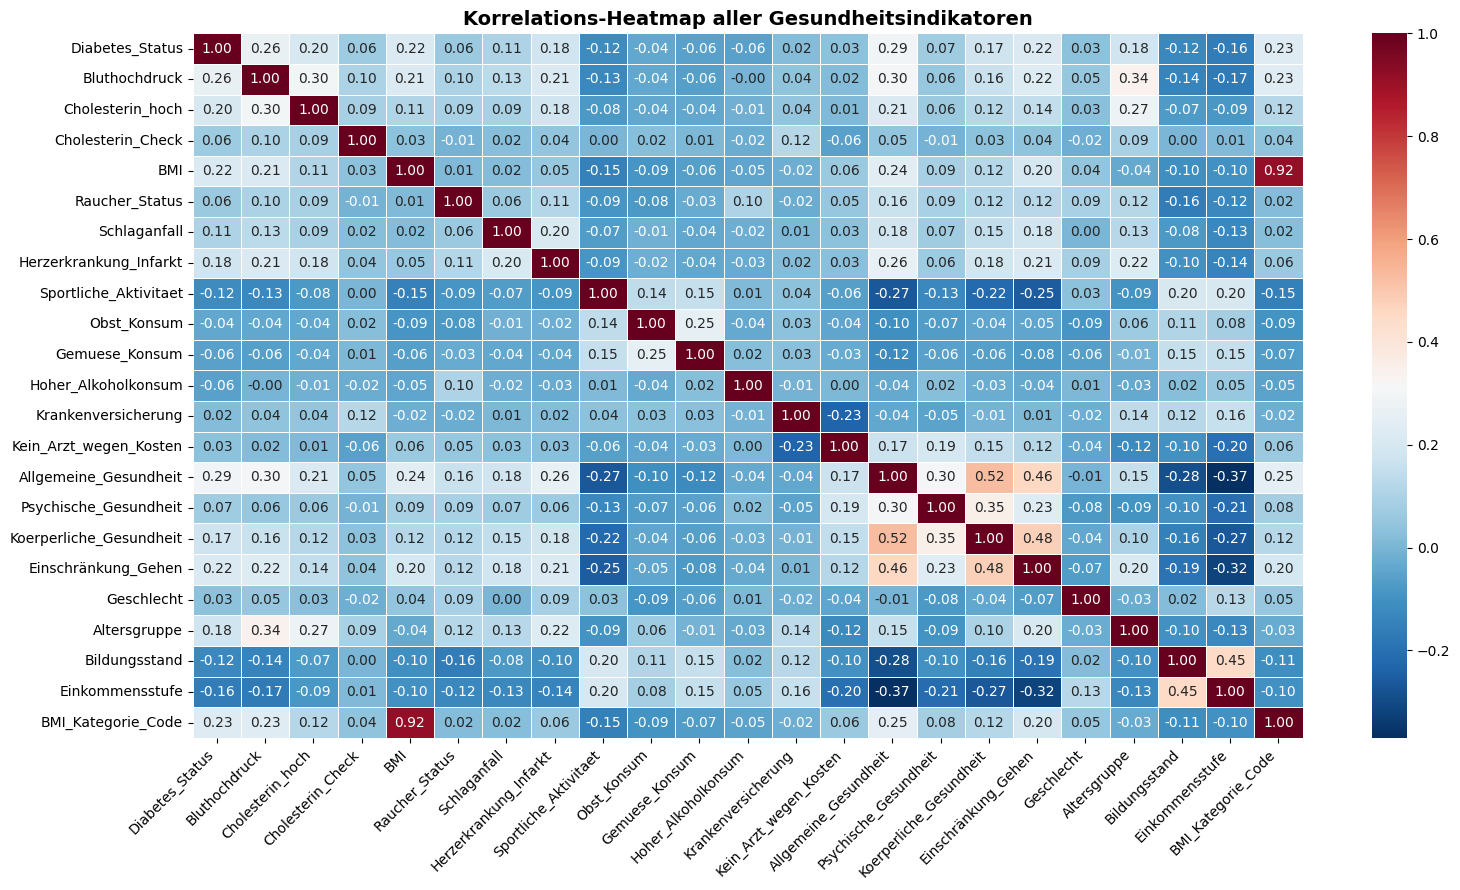

In [16]:
# Grafik: Korrelations-Heatmap aller Gesundheitsindikatoren

# Korrelationsmatrix berechnen mit numerischen Spalten/DatenTypen
df_numerisch = df.select_dtypes(include=["number"])
corr_matrix = df_numerisch.corr()

plt.figure(figsize=(16, 9))

# Heatmap plotten
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",  # colorblind
    fmt=".2f",
    linewidths=0.5
)

# Titel & Achsen
plt.title("Korrelations-Heatmap aller Gesundheitsindikatoren", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Anmerkung:  
Der Fokus für die Datenanlyse wird auf den Faktoren BMI, Bluthochdruck, Cholesterin_hoch, Altersgruppe, Bildungsstand, Einkommensstufe, Allgemeine_Gesundheit, Psychische_Gesundheit und Koerperliche_Gesundheit liegen.

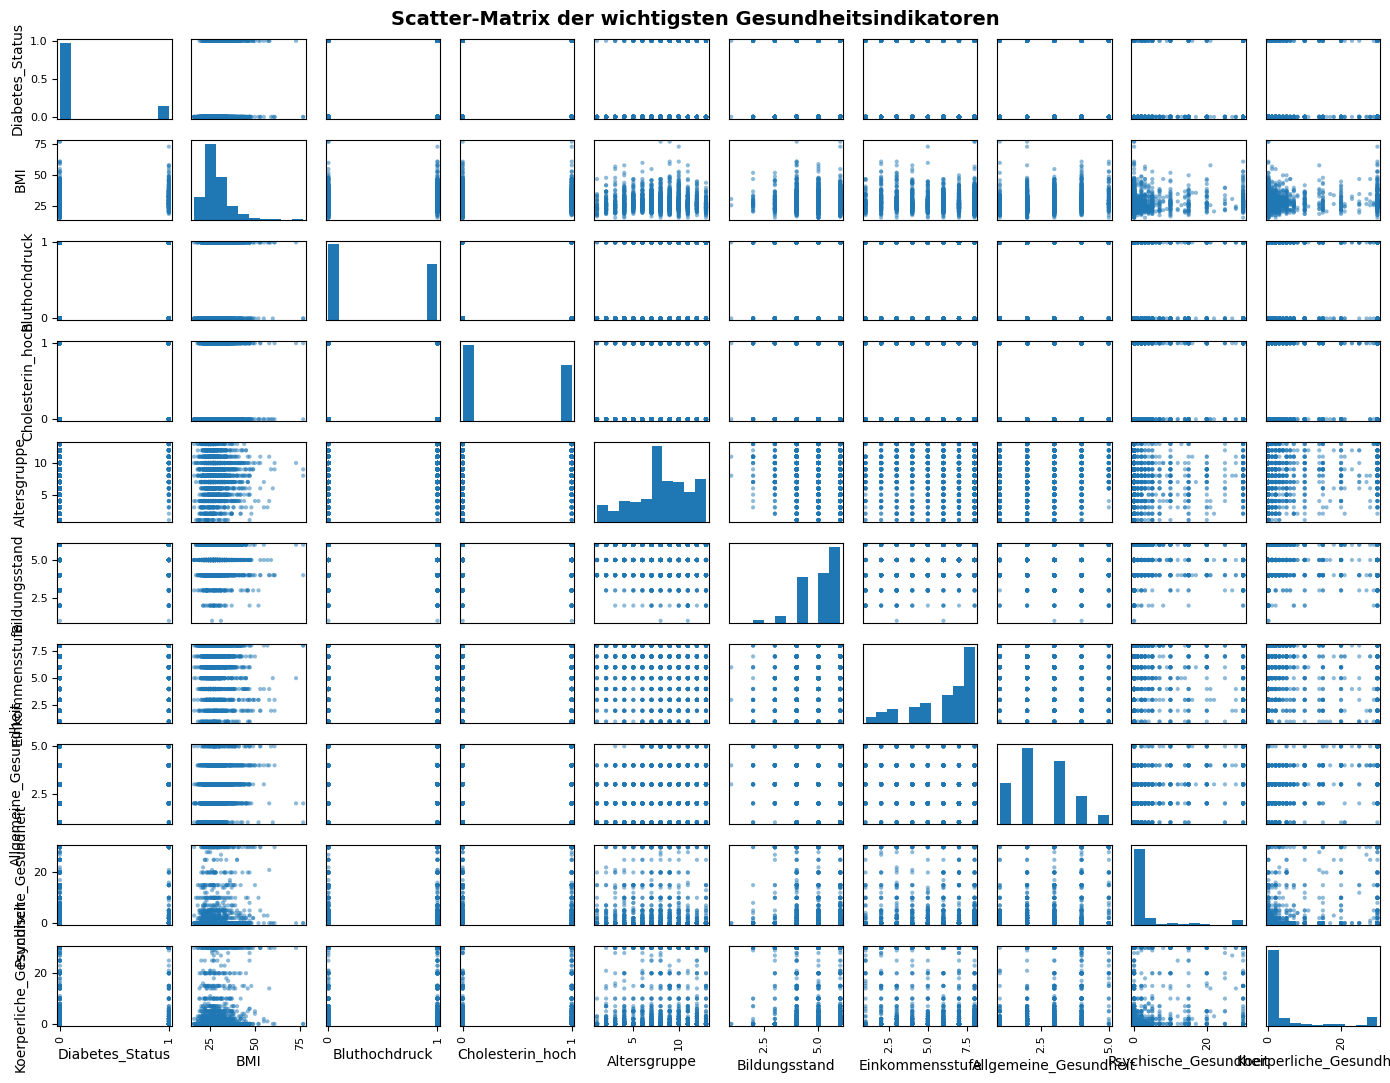

In [17]:
# Grafik: Scatter-Matrix der wichtigsten Gesundheitsindikatoren

kern_merkmale = [
    "Diabetes_Status", 
    "BMI", 
    "Bluthochdruck", 
    "Cholesterin_hoch", 
    "Altersgruppe", 
    "Bildungsstand", 
    "Einkommensstufe", 
    "Allgemeine_Gesundheit", 
    "Psychische_Gesundheit", 
    "Koerperliche_Gesundheit"
]

# Stichprobe ziehen
df_auswahl = df[kern_merkmale].sample(n=2000, random_state=42)

# Scatter-Matrix plotten
axes = pd.plotting.scatter_matrix(
    df_auswahl,
    figsize=(14, 11),
    alpha=0.5,
    diagonal="hist", #"kde"
    grid=False
)

# Titel hinzufügen
plt.suptitle("Scatter-Matrix der wichtigsten Gesundheitsindikatoren", fontsize=14, fontweight="bold", y=0.98)

plt.tight_layout()
plt.show()

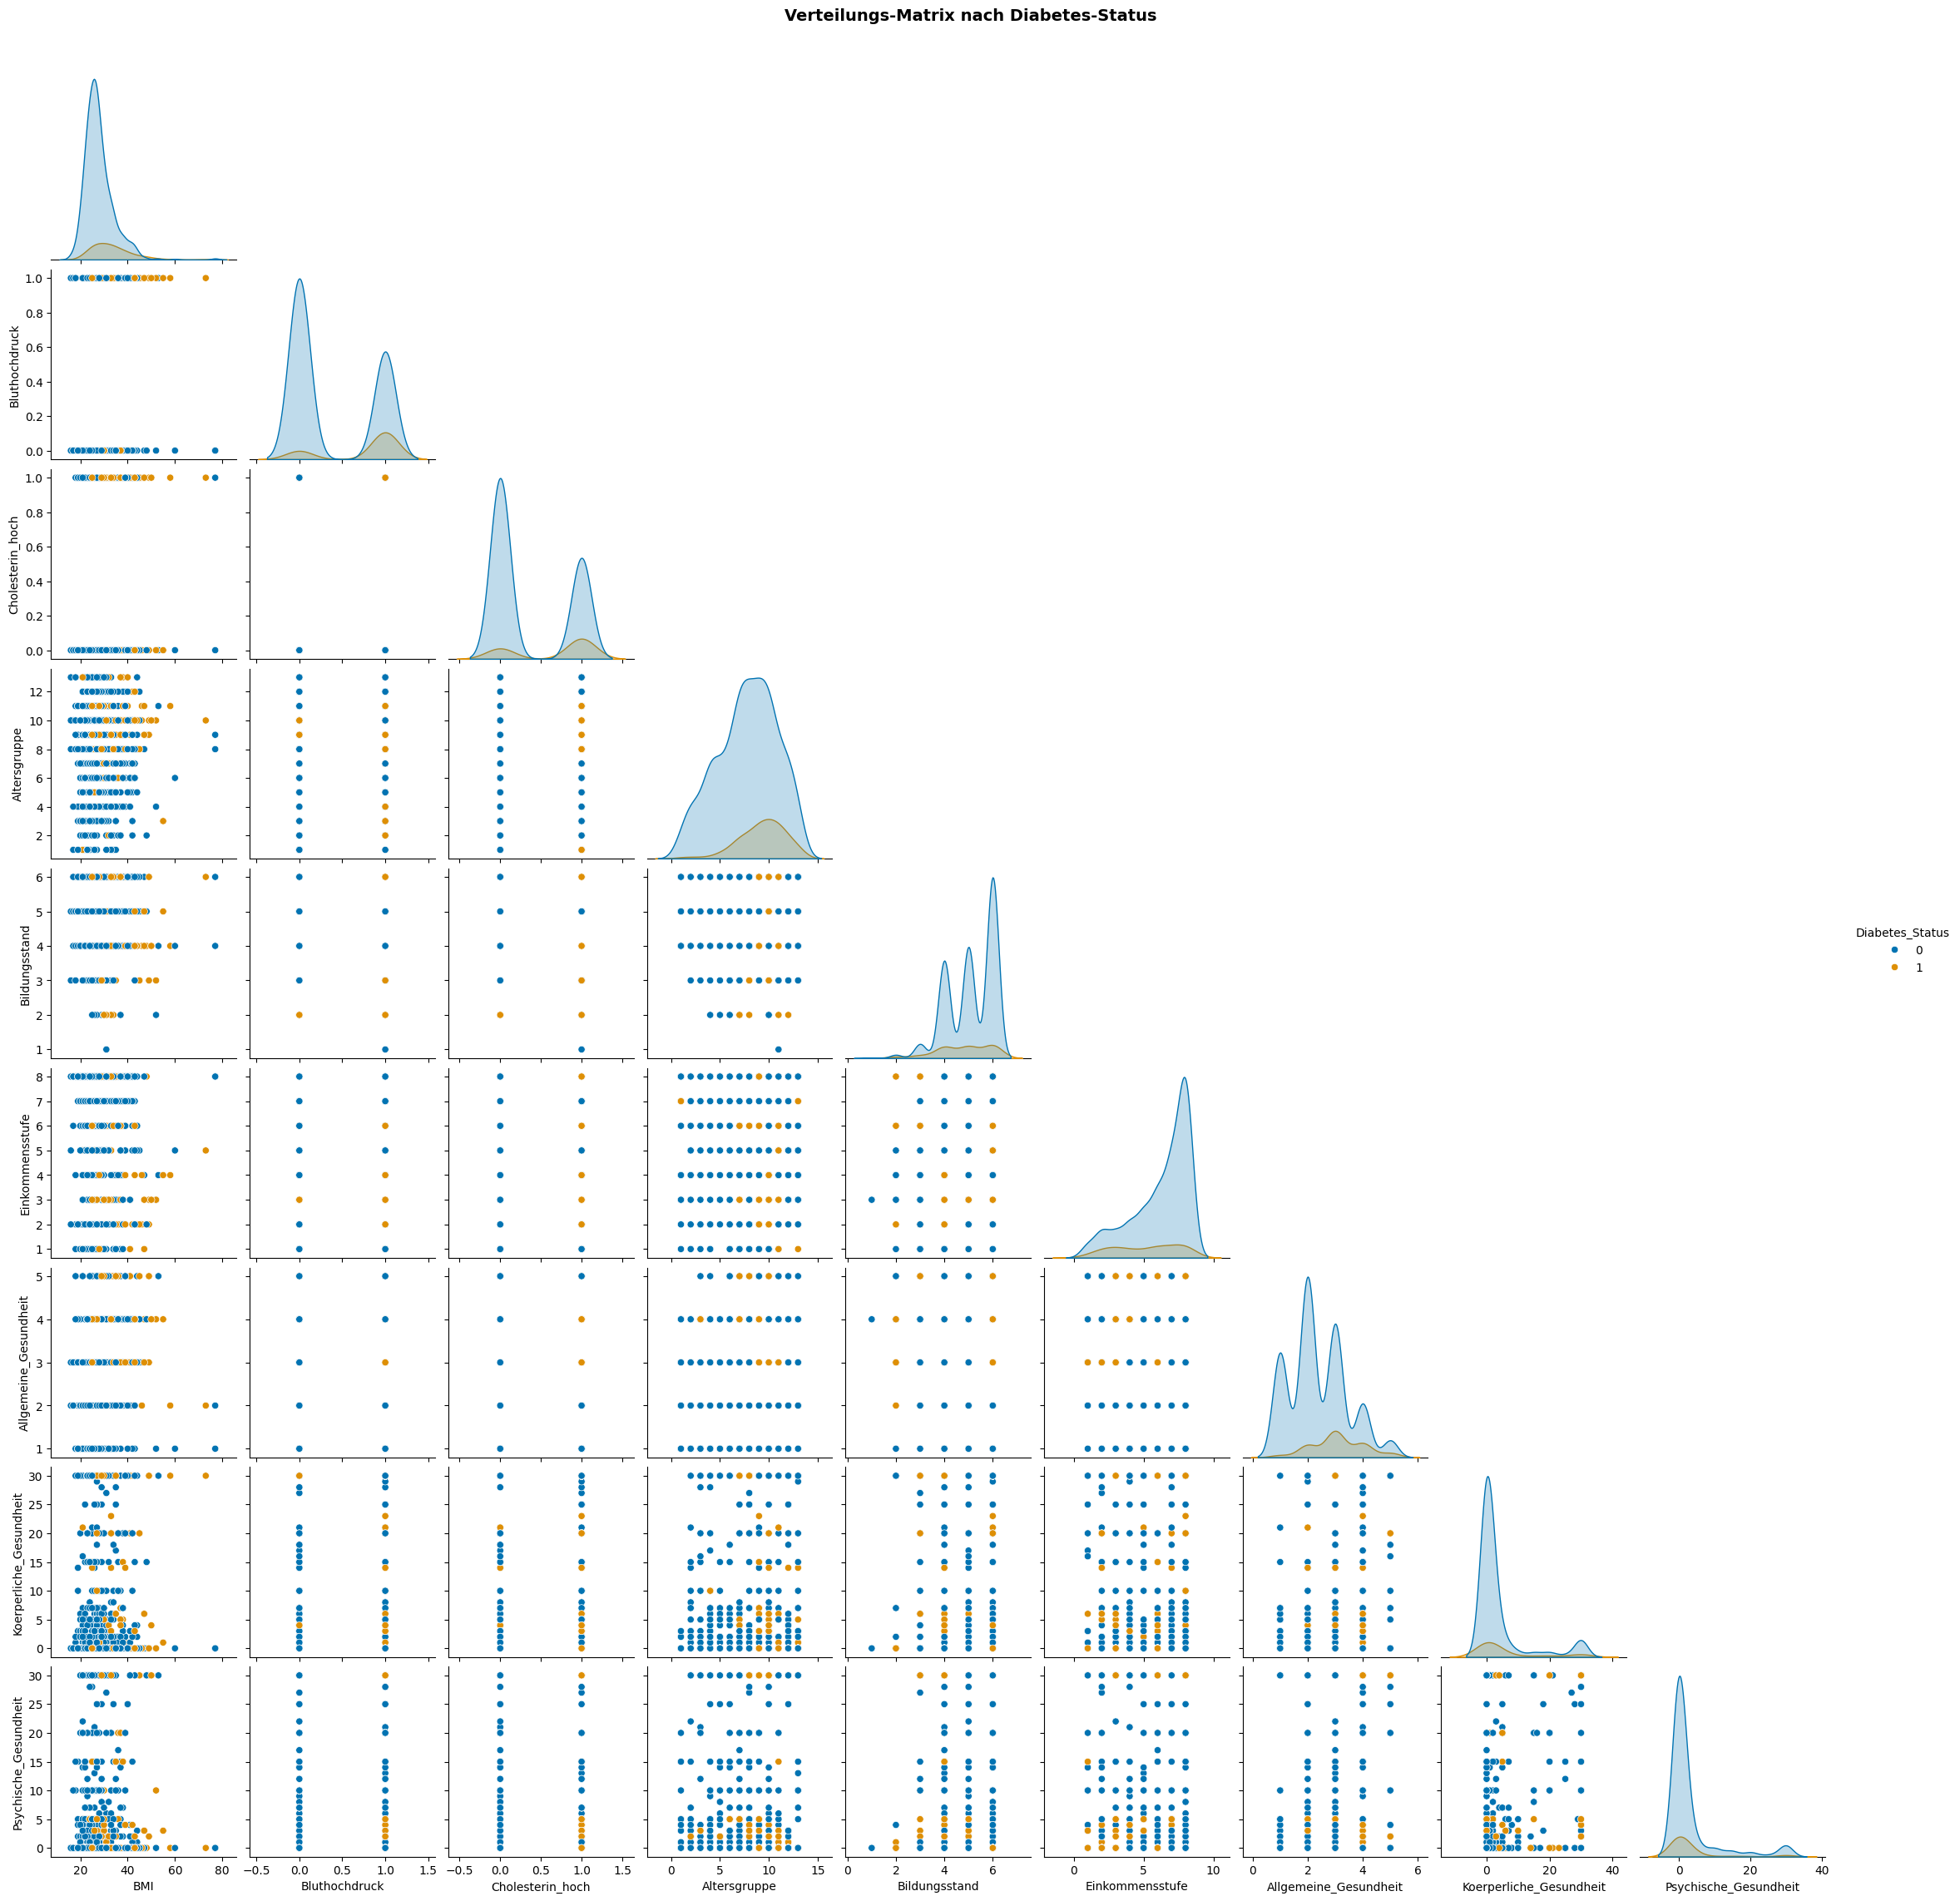

In [18]:
# Grafik: Verteilungs-Matrix nach Diabetes-Status

# Stichprobe für besseres Rendering ziehen
df_sample = df.sample(n=1000, random_state=42)

uebersicht_spalten = [
    "BMI", 
    "Bluthochdruck", 
    "Cholesterin_hoch", 
    "Altersgruppe",
    "Bildungsstand", 
    "Einkommensstufe", 
    "Allgemeine_Gesundheit",
    "Koerperliche_Gesundheit",
    "Psychische_Gesundheit"
    
]

# Pairplot erstellen
g = sns.pairplot(
    data=df_sample[uebersicht_spalten + ["Diabetes_Status"]],
    hue="Diabetes_Status",
    palette="colorblind",
    vars=uebersicht_spalten,
    corner=True,
    diag_kind="kde"
)

# Titel hinzufügen
g.figure.suptitle("Verteilungs-Matrix nach Diabetes-Status", fontsize=14, fontweight="bold", y=1.02)

plt.show()

3. Datenanalyse und Visualisierungen

<div style="margin-left: 20px;">
3.1 Übersicht der 9 ausgewählten Risikofaktoren<br>
3.2 Geschlecht<br>
3.3 BMI<br>
3.4 Altersgruppen nach Geschlecht<br>
3.5 Herz Kreislauf<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.5.1 Bluthochdruck<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.5.2 Cholesterin<br>
3.6 Demografie<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.6.1 Bildungsstand<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.6.2 Einkommensstufe<br>
3.7 Gesundheit<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.1 Allgemeine Gesundheit Balkendiagramm<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.2 Körperliche Gesundheit Balkendiagramm<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.3 Psychische Gesundheit Balkendiagramm<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.4 Allgemeine Gesundheit Liniendiagramm<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.5 Körperliche Gesundheit Liniendiagramm<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.7.6 Psychische Gesundheit Liniendiagramm<br>
3.8 Logistische Regression
</div>

Der Datensatz bleibt so organisiert, dass im Folgenden statistische Häufigkeiten zwischen den Gruppen analysiert werden können.<br>
Die Daten sind strukturell in (x) und (y) aufgeteilt und deshalb gut für eine logistische Regressionsanalyse geeignet.

Wie oben erwähnt wird der Fokus für die Datenanalyse auf den Faktoren BMI, Bluthochdruck, Cholesterin_hoch, Altersgruppe, Bildungsstand, Einkommensstufe, Allgemeine_Gesundheit, Koerperliche_Gesundheit und Psychische_Gesundheit liegen.

  
  
3.1 Übersicht der neun ausgewählten Risikofaktoren

In [19]:
# Berechnungen: Übersicht über 9 ausgewählte Faktoren

# Baseline
baseline_rate = df["Diabetes_Status"].mean() * 100   # Durchschnitt Diabetes Status alle

# Raten für die Risikogruppen berechnen (in %)
rate_bluthochdruck = df[df["Bluthochdruck"] == 1]["Diabetes_Status"].mean() * 100
rate_bmi = df[df["BMI"] >= 30]["Diabetes_Status"].mean() * 100
rate_cholesterin = df[df["Cholesterin_hoch"] == 1]["Diabetes_Status"].mean() * 100
rate_alter = df[df["Altersgruppe"] >= 9]["Diabetes_Status"].mean() * 100
rate_allg_ges = df[df["Allgemeine_Gesundheit"] >= 4]["Diabetes_Status"].mean() * 100
rate_psych_ges = df[df["Psychische_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100
rate_koerp_ges = df[df["Koerperliche_Gesundheit"] > 14]["Diabetes_Status"].mean() * 100
rate_bildung = df[df["Bildungsstand"] == 1]["Diabetes_Status"].mean() * 100
rate_einkommen = df[df["Einkommensstufe"] == 1]["Diabetes_Status"].mean() * 100

# In DataFrame zusammenfassen
faktoren_data_10 = pd.DataFrame({
    "Risikofaktor": [
        "Bluthochdruck", "BMI", "Cholesterin_hoch", "Altersgruppe",
        "Allgemeine_Gesundheit", "Psychische_Gesundheit", 
        "Koerperliche_Gesundheit", "Bildungsstand", "Einkommensstufe"
    ],
    "Diabetes_Rate": [
        rate_bluthochdruck, rate_bmi, rate_cholesterin, rate_alter,
        rate_allg_ges, rate_psych_ges, rate_koerp_ges, rate_bildung, rate_einkommen
    ]
})

# Sortieren
faktoren_data_10 = faktoren_data_10.sort_values(by="Diabetes_Rate", ascending=False)

#Check
display(faktoren_data_10)

,Risikofaktor,Diabetes_Rate
4,Allgemeine_Gesundheit,32.915626
6,Koerperliche_Gesundheit,28.590738
7,Bildungsstand,27.011494
0,Bluthochdruck,24.445690
8,Einkommensstufe,24.289063
1,BMI,23.399847
2,Cholesterin_hoch,22.014853
5,Psychische_Gesundheit,21.202396
3,Altersgruppe,19.657603


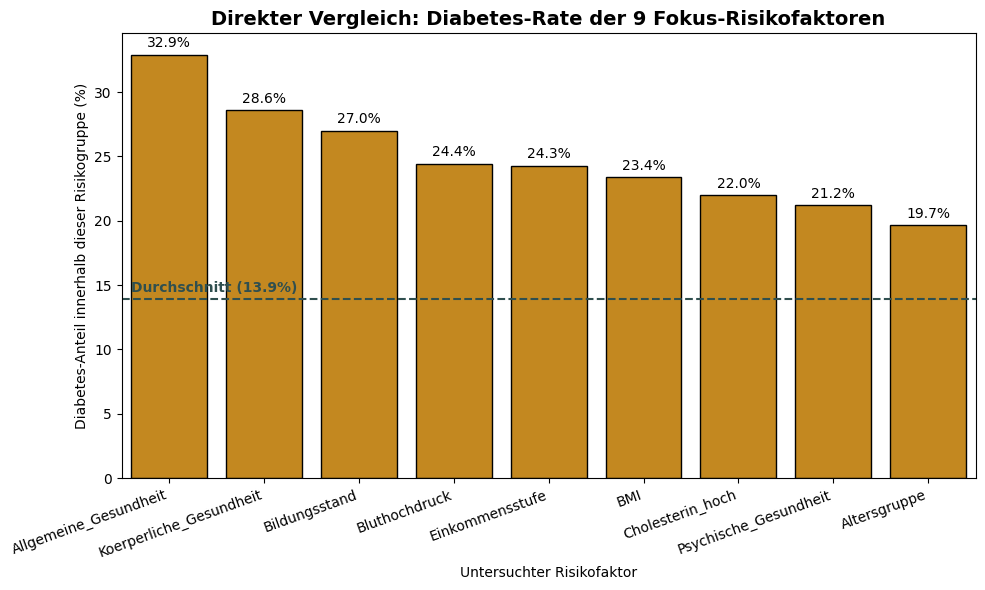

In [20]:
# Grafik: Übersicht über 9 ausgewählte Faktoren
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=faktoren_data_10,
    x="Risikofaktor",
    y="Diabetes_Rate",
    color=sns.color_palette("colorblind")[1],  #orange
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Direkter Vergleich: Diabetes-Rate der 9 Fokus-Risikofaktoren", fontsize=14, fontweight="bold")
plt.xlabel("Untersuchter Risikofaktor")
plt.ylabel("Diabetes-Anteil innerhalb dieser Risikogruppe (%)")

plt.xticks(rotation=20, ha="right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Fazit zu Kapitel 3.1 Übersicht der Risikofaktoren<br>
<br>
Im unbereinigten, direkten Vergleich weisen Personen mit eingeschränkter allgemeiner Gesundheit (32,9 %), 
schlechter körperlicher Gesundheit (28,6 %) und niedriger Bildung (27,0 %) die höchsten Diabetes-Raten auf. 
Auch Bluthochdruck (24,4 %) und geringes Einkommen (24,3 %) heben die Rate massiv an. 
Alle neun Fokus-Gruppen liegen deutlich über dem Stichproben-Durchschnitt von 13,9 %.

3.2 Geschlecht

In [21]:
#Check
print(f"Gesamtanzahl der Datensätze: {len(df['Geschlecht']):,}")
print("\nVerteilung nach Geschlecht:")
display(df['Geschlecht'].map({0.0: 'Frauen (0)', 1.0: 'Männer (1)'}).value_counts().to_frame(name="Anzahl"))

Gesamtanzahl der Datensätze: 253,680

Verteilung nach Geschlecht:


,Anzahl
Geschlecht,
Frauen (0),141974
Männer (1),111706


In [22]:
# Berechnungen: Zusammensetzung gesamt und nach Geschlecht

# Prozentualen Anteil berechnen (Total = 100%)
gesamt_aufteilung = pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100

#Check
print("Geschlecht 0/1 Frauen/Männer  Diabetes-Status 0/1 Gesund/Diabetes:")
display(gesamt_aufteilung)

Geschlecht 0/1 Frauen/Männer  Diabetes-Status 0/1 Gesund/Diabetes:


Diabetes_Status,0,1
Geschlecht,,
0,48.708215,7.257569
1,37.358483,6.675733


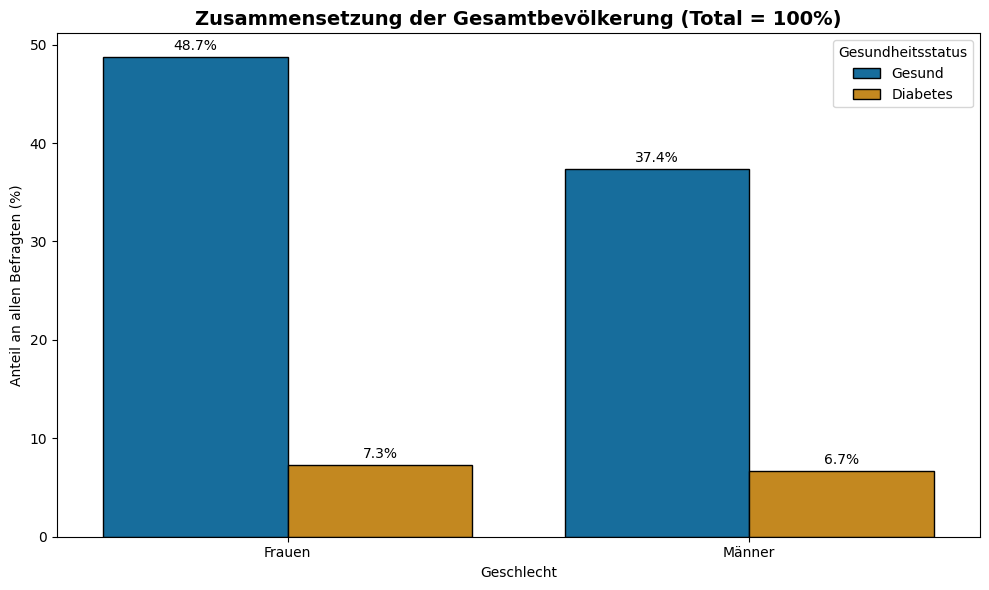

In [23]:
# Berechnung und Grafik: Zusammensetzung der Gesamtbevölkerung

# Anteile berechnen
gesamt_aufteilung = pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="all") * 100  
gesamt_df = gesamt_aufteilung.stack().reset_index()
gesamt_df.columns = ["Geschlecht", "Diabetes_Status", "Prozent_an_Gesamtpopulation"]

# Text-Mapping
gesamt_df["Geschlecht"] = gesamt_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})
gesamt_df["Diabetes_Status"] = gesamt_df["Diabetes_Status"].map({0: "Gesund", 1: "Diabetes"})

plt.figure(figsize=(10, 6))

# Balkendiagramm
ax = sns.barplot(
    data=gesamt_df,
    x="Geschlecht",
    y="Prozent_an_Gesamtpopulation",
    hue="Diabetes_Status",
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Zusammensetzung der Gesamtbevölkerung (Total = 100%)", fontsize=14, fontweight="bold")
plt.xlabel("Geschlecht")
plt.ylabel("Anteil an allen Befragten (%)")

plt.legend(title="Gesundheitsstatus", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

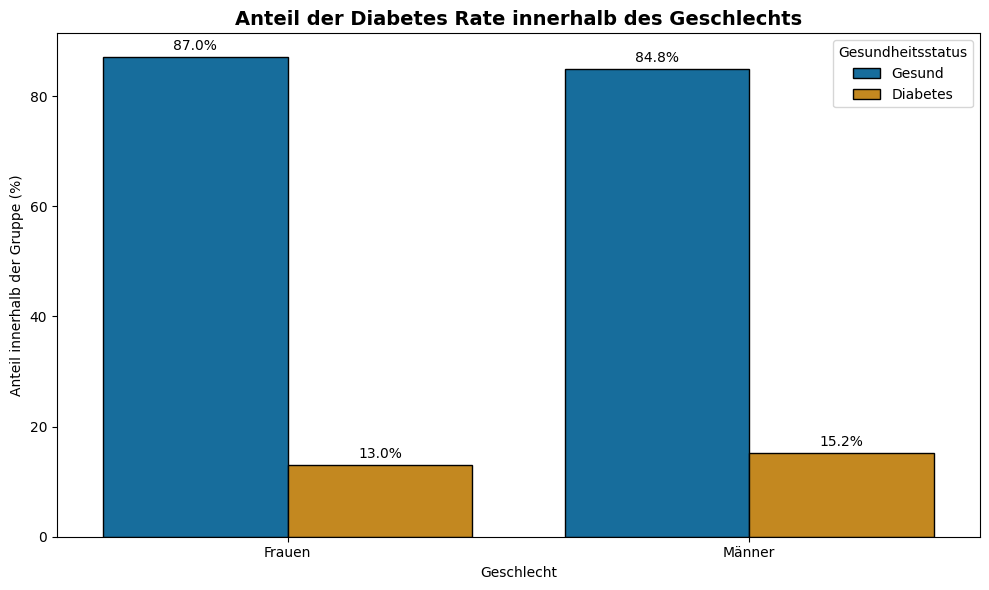

In [24]:
# Berechnung und Grafik: nach Geschlecht

# Anteile berechnen
gesamt_aufteilung = pd.crosstab(df["Geschlecht"], df["Diabetes_Status"], normalize="index") * 100  
gesamt_df = gesamt_aufteilung.stack().reset_index()
gesamt_df.columns = ["Geschlecht", "Diabetes_Status", "Prozent_an_Gesamtpopulation"]

# Text-Mapping
gesamt_df["Geschlecht"] = gesamt_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})
gesamt_df["Diabetes_Status"] = gesamt_df["Diabetes_Status"].map({0: "Gesund", 1: "Diabetes"})

plt.figure(figsize=(10, 6))

# Balkendiagramm
ax = sns.barplot(
    data=gesamt_df,
    x="Geschlecht",
    y="Prozent_an_Gesamtpopulation",
    hue="Diabetes_Status",
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Anteil der Diabetes Rate innerhalb des Geschlechts", fontsize=14, fontweight="bold")
plt.xlabel("Geschlecht")
plt.ylabel("Anteil innerhalb der Gruppe (%)")

plt.legend(title="Gesundheitsstatus", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Fazit zu Kapitel 3.2 Geschlecht

Die Stichprobe zeigt einen leichten Frauenüberschuss (56 %). 
Männer sind mit einer Diabetes-Rate von 15,2 % etwas häufiger betroffen als Frauen mit 13,0 %. 
ezogen auf die Gesamtpopulation stellen nicht-diabetische Frauen (48,7 %) und nicht-diabetische Männer (37,4 %) die größten Gruppen dar.

3.3 BMI

In [25]:
# Berechnung: Absolute Häufigkeiten und Prozentanteile nach WHO-BMI-Klassen

# Absolute Anzahl und Raten berechnen
bmi_counts = df["BMI_Kategorie_Text"].value_counts()
bmi_rates_who = df.groupby("BMI_Kategorie_Text")["Diabetes_Status"].mean() * 100

# neues DF und nach WHO sortieren
bmi_zusammenfassung = pd.DataFrame({"Anzahl_Personen": bmi_counts, "Diabetes_Rate_%": bmi_rates_who }).reindex(reihenfolge_who)

#Check
print("Übersicht der WHO-BMI-Kategorien im Datensatz:")
display(bmi_zusammenfassung)

Übersicht der WHO-BMI-Kategorien im Datensatz:


,Anzahl_Personen,Diabetes_Rate_%
BMI_Kategorie_Text,,
Untergewicht (< 18.5),3127,5.404541
Normalgewicht (18.5 - 24.9),68953,5.696634
Übergewicht (25.0 - 29.9),93749,11.404922
Adipositas Grad I (30.0 - 34.9),53451,19.234439
Adipositas Grad II (35.0 - 39.9),20663,27.435513
Adipositas Grad III (>= 40.0),13737,33.537162


In [26]:
# Anzahl nach BMI Kategorien

# gesamt
display(df[["BMI", "BMI_Kategorie_Text"]].value_counts().sort_index())

# nach Geschlecht
kategorie_geschlecht = df[["BMI_Kategorie_Text", "Geschlecht"]].value_counts().sort_index()      # 0=Frauen / 1=Männer
display(kategorie_geschlecht)

BMI  BMI_Kategorie_Text           
12   Untergewicht (< 18.5)              6
13   Untergewicht (< 18.5)             21
14   Untergewicht (< 18.5)             41
15   Untergewicht (< 18.5)            132
16   Untergewicht (< 18.5)            348
                                     ... 
91   Adipositas Grad III (>= 40.0)      1
92   Adipositas Grad III (>= 40.0)     32
95   Adipositas Grad III (>= 40.0)     12
96   Adipositas Grad III (>= 40.0)      1
98   Adipositas Grad III (>= 40.0)      7
Name: count, Length: 84, dtype: int64

BMI_Kategorie_Text                Geschlecht
Adipositas Grad I (30.0 - 34.9)   0             26662
                                  1             26789
Adipositas Grad II (35.0 - 39.9)  0             11735
                                  1              8928
Adipositas Grad III (>= 40.0)     0              8950
                                  1              4787
Normalgewicht (18.5 - 24.9)       0             44947
                                  1             24006
Untergewicht (< 18.5)             0              2461
                                  1               666
Übergewicht (25.0 - 29.9)         0             47219
                                  1             46530
Name: count, dtype: int64

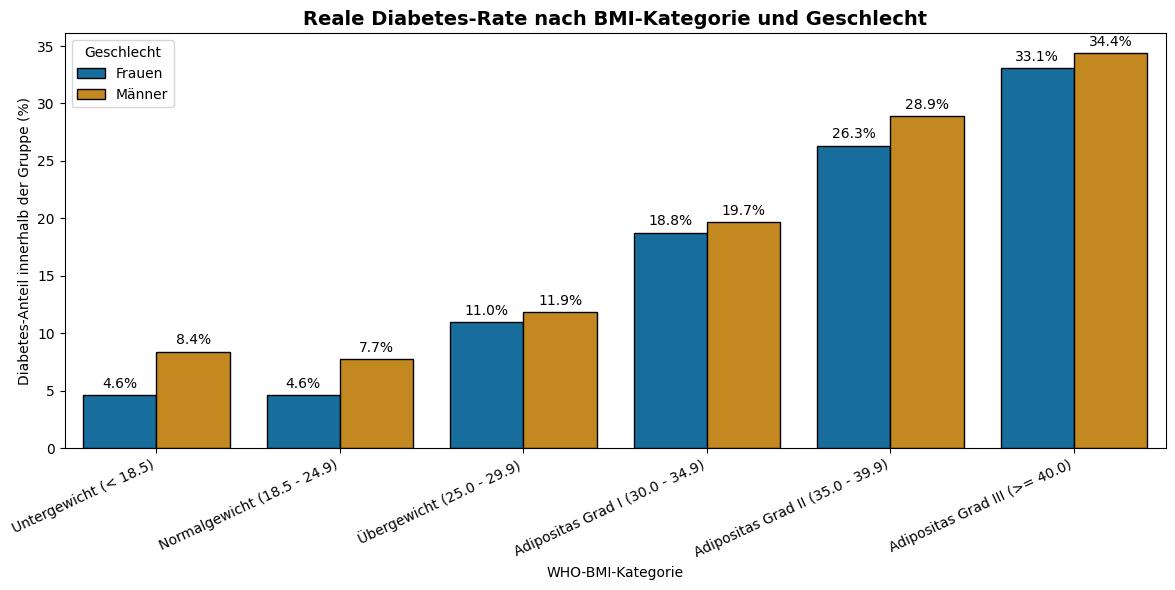

In [27]:
# Berechnung und Grafik: Diabetes-Rate nach BMI-Kategorie und Geschlecht

# Raten berechnen
bmi_geschlecht_rates = (df.groupby(["BMI_Kategorie_Text", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()       
bmi_geschlecht_rates["Geschlecht"] = bmi_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

plt.figure(figsize=(12, 6))

# Gruppiertes Balkendiagramm
ax = sns.barplot(
    data=bmi_geschlecht_rates,
    x="BMI_Kategorie_Text",
    y="Diabetes_Status",
    hue="Geschlecht",
    order=reihenfolge_who,
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Reale Diabetes-Rate nach BMI-Kategorie und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("WHO-BMI-Kategorie")
plt.ylabel("Diabetes-Anteil innerhalb der Gruppe (%)")

plt.xticks(rotation=25, ha="right")
plt.legend(title="Geschlecht", loc="upper left")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

In [28]:
# Berechnungen: Risikopunkt nach BMI und Geschlecht

# 1. Relevanten BMI-Bereich filtern
df_kurve_gefiltert = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]

# 2. Rate berechnen und Geschlecht in Spalten aufteilen
bmi_trend_geschlecht = (df_kurve_gefiltert.groupby(["BMI", "Geschlecht"])["Diabetes_Status"].mean() * 100).unstack()

# 3. Spalten benennen (0 = Frauen, 1 = Männer)
bmi_trend_geschlecht = bmi_trend_geschlecht.rename(columns={0: "Frauen_%", 1: "Männer_%"})

# Check
display(bmi_trend_geschlecht)

Geschlecht,Frauen_%,Männer_%
BMI,,
18,3.706246,8.381503
19,2.766798,6.480118
20,3.151345,6.245353
21,4.056930,7.445443
22,4.227660,6.772110
23,4.929162,7.565185
24,6.412602,8.630278
25,7.700455,9.396496
26,9.372453,10.068863


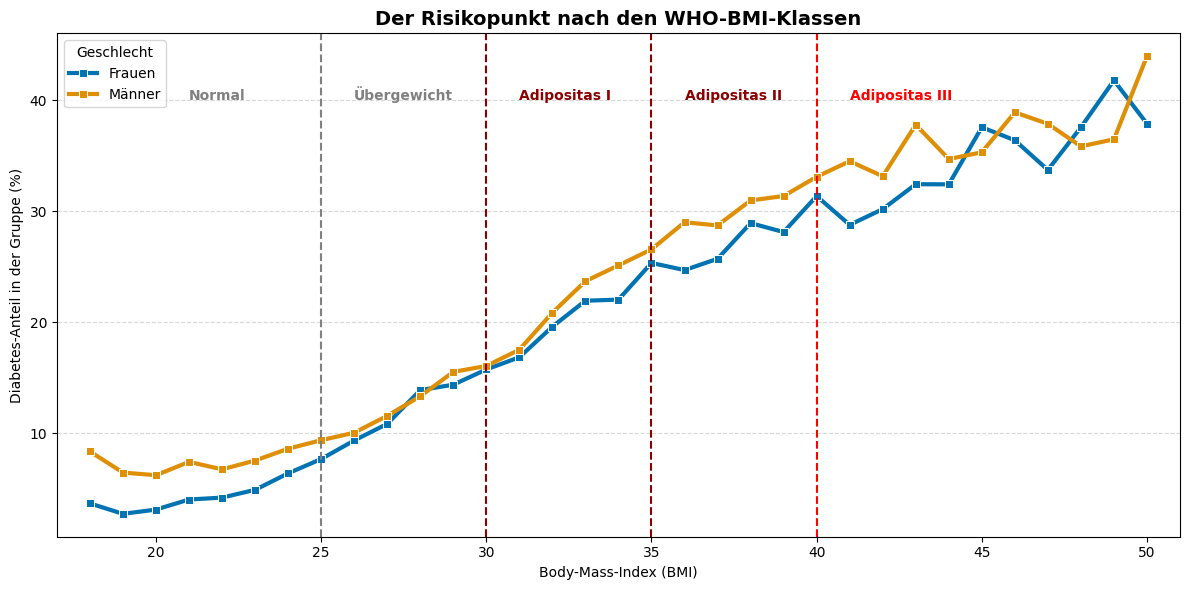

In [29]:
# Grafik: Der Risikopunkt nach den WHO-BMI-Klassen (Männer und Frauen)

# Filter und Berechnung
df_kurve = df[(df["BMI"] >= 18) & (df["BMI"] <= 50)]
trend_geschlecht = df_kurve.groupby(["BMI", "Geschlecht"])["Diabetes_Status"].mean().reset_index()
trend_geschlecht["Diabetes_Status"] *= 100
trend_geschlecht["Geschlecht"] = trend_geschlecht["Geschlecht"].map({0: "Frauen", 1: "Männer"})

plt.figure(figsize=(12, 6))

# Liniendiagramm
ax = sns.lineplot(
    data=trend_geschlecht,
    x="BMI",
    y="Diabetes_Status",
    hue="Geschlecht",
    palette="colorblind",
    linewidth=3,
    marker="s"          # Quadratische Datenpunkte auf der Linie
)

# WHO-Klassen Grenzlinien (Risikopunkt)
plt.axvline(x=25, color="gray", linestyle="--")
plt.axvline(x=30, color="darkred", linestyle="--")
plt.axvline(x=35, color="darkred", linestyle="--")
plt.axvline(x=40, color="red", linestyle="--")

# Textmarkierungen einheitlich auf Höhe 40% 
plt.text(21, 40, "Normal", color="gray", fontweight="bold")
plt.text(26, 40, "Übergewicht", color="gray", fontweight="bold")
plt.text(31, 40, "Adipositas I", color="darkred", fontweight="bold")
plt.text(36, 40, "Adipositas II", color="darkred", fontweight="bold")
plt.text(41, 40, "Adipositas III", color="red", fontweight="bold")

# Titel & Achsen
plt.title("Der Risikopunkt nach den WHO-BMI-Klassen", fontsize=14, fontweight="bold")
plt.xlabel("Body-Mass-Index (BMI)")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

# Gitter und Legende
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xlim(17, 51)
plt.legend(title="Geschlecht", loc="upper left")

plt.tight_layout()
plt.show()

Fazit zu Kapitel 3.3 BMI

Das Diabetes-Risiko steigt mit zunehmenden WHO-Gewichtsklassen drastisch an. 
Während die Rate im Normalgewicht bei nur 4,7 % liegt, klettert sie in der Adipositas Grad I auf 16,6 % 
und erreicht in Grad III einen Höchstwert von 34,4 %. 
Über alle BMI-Klassen hinweg weisen Männer ein konstant höheres Erkrankungsrisiko auf als Frauen.

3.4 Altersgruppen nach Geschlecht

In [30]:
# Raten berechnen
alter_geschlecht_rates = (df.groupby(["Altersgruppe", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
alter_geschlecht_rates["Geschlecht_Text"] = alter_geschlecht_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

#Check
display(alter_geschlecht_rates[["Altersgruppe", "Geschlecht_Text", "Diabetes_Status"]])

,Altersgruppe,Geschlecht_Text,Diabetes_Status
0,1,Frauen,1.639344
1,1,Männer,1.116751
2,2,Frauen,2.230018
3,2,Männer,1.413917
4,3,Frauen,3.150775
5,3,Männer,2.430350
6,4,Frauen,4.737864
7,4,Männer,4.263693
8,5,Frauen,6.304729
9,5,Männer,6.765418


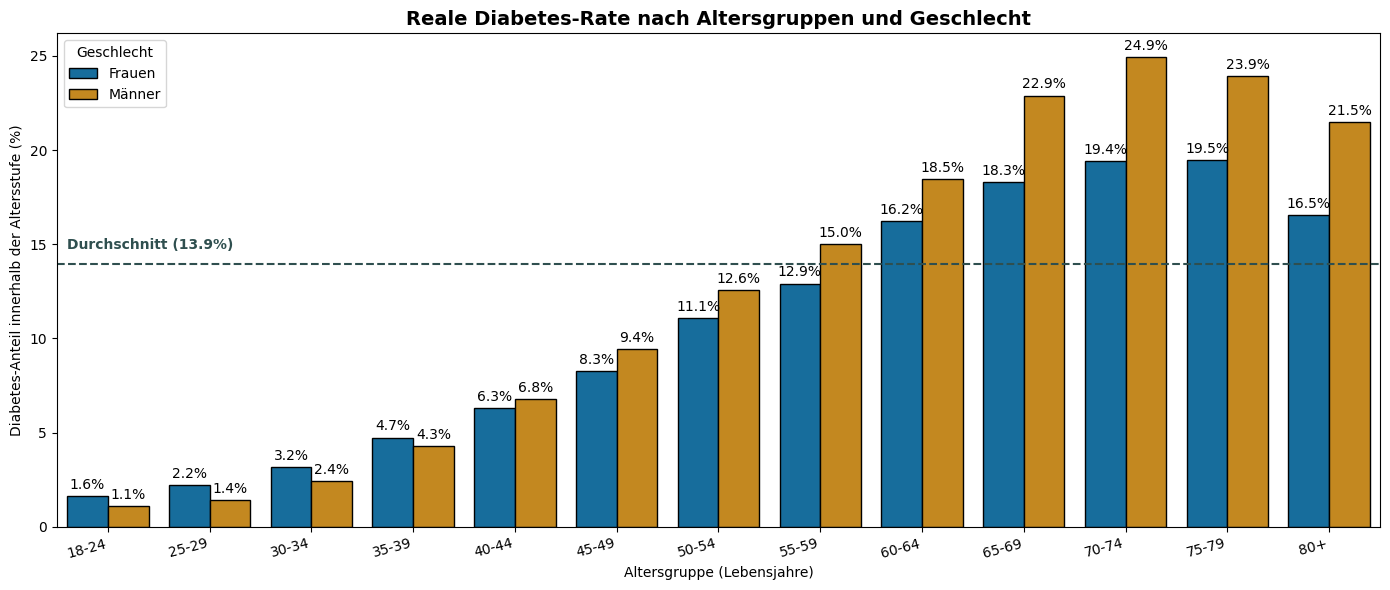

In [31]:
# Grafik: Diabetesrate nach Alter und Geschlecht

# sicheres Text-Mapping für X-Achse 
alter_mapping = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44", 6: "45-49",
    7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
alter_geschlecht_rates["Altersgruppe_Text"] = alter_geschlecht_rates["Altersgruppe"].map(alter_mapping)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=alter_geschlecht_rates,
    x="Altersgruppe_Text",  # Nutzt die gemappten Texte für eine fehlerfreie X-Achse
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black"
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.8,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold"
)

# Titel & Achsen
plt.title("Reale Diabetes-Rate nach Altersgruppen und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Altersgruppe (Lebensjahre)")
plt.ylabel("Diabetes-Anteil innerhalb der Altersstufe (%)")

plt.legend(title="Geschlecht", loc="upper left")
plt.xticks(rotation=15, ha="right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Fazit Kapitel 3.4 Altersgruppen nach Geschlecht

 Das Diabetes-Risiko korreliert stark mit dem Lebensalter. 
 Unter 35 Jahren bleibt die Rate minimal bei unter 2 %, bevor ab Mitte 40 eine deutliche Risikobeschleunigung einsetzt. 
 Die höchsten Fallzahlen werden in den Altersstufen zwischen 65 und 79 Jahren mit über 25 % verzeichnet, wobei Männer ab dem mittleren Alter durchgehend höhere Raten zeigen.

3.5 Herz-Kreislauf 

3.5.1 Bluthochdruck<br>
3.5.2 Cholesterin

In [32]:
# Berechnung: Bluthochdruck und Cholesterin nach Geschlecht

# Bluthochdruck
bp_geschlecht = (df.groupby("Geschlecht")["Bluthochdruck"].mean() * 100).reset_index()
bp_geschlecht["Faktor"] = "Bluthochdruck"
bp_geschlecht.rename(columns={"Bluthochdruck": "Anteil"}, inplace=True)

# Cholesterin
chol_geschlecht = (df.groupby("Geschlecht")["Cholesterin_hoch"].mean() * 100).reset_index()
chol_geschlecht["Faktor"] = "Hohes Cholesterin"
chol_geschlecht.rename(columns={"Cholesterin_hoch": "Anteil"}, inplace=True)

# Zusammenführen und Text mappen
herz_risiko_df = pd.concat([bp_geschlecht, chol_geschlecht], axis=0)
herz_risiko_df["Geschlecht_Text"] = herz_risiko_df["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Check
display(herz_risiko_df[["Faktor", "Geschlecht_Text", "Anteil"]])

,Faktor,Geschlecht_Text,Anteil
0,Bluthochdruck,Frauen,40.608140
1,Bluthochdruck,Männer,45.813117
0,Hohes Cholesterin,Frauen,41.044135
1,Hohes Cholesterin,Männer,44.150717


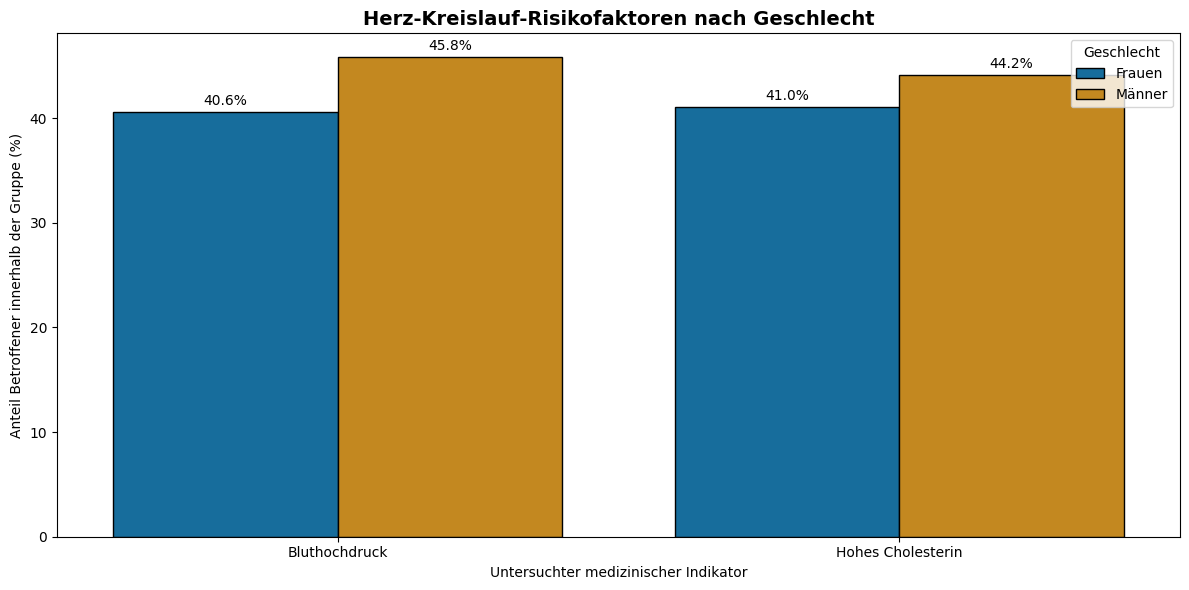

In [33]:
# Grafik: Bluthochdruck und Cholesterin nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=herz_risiko_df,
    x="Faktor",
    y="Anteil",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Titel & Achsen
plt.title("Herz-Kreislauf-Risikofaktoren nach Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Untersuchter medizinischer Indikator")
plt.ylabel("Anteil Betroffener innerhalb der Gruppe (%)")

plt.legend(title="Geschlecht", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Fazit Kapitel 3.5 Herz-Kreislauf

Beide Vorerkrankungen sind mit Raten von über 40 % extrem weit verbreitet. 
Beim Bluthochdruck ist die Schere zwischen den Geschlechtern am größten: Männer sind mit 45,8 % spürbar häufiger betroffen als Frauen (40,6 %). 
Beim hohen Cholesterin liegen die Gruppen näher zusammen, wobei Männer mit 44,2 % ebenfalls leicht über den Frauen (41,0 %) liegen.

3.6 Demografie

3.6.1 Bildungsstand 

In [34]:
# Berechnung Bildung nach Geschlecht

# Raten berechnen
bildung_rates = (df.groupby(["Bildungsstand", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
bildung_rates["Geschlecht_Text"] = bildung_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping für X-Achse
bildung_mapping = {
    1: "Keine/Grundschule",
    2: "Elementarstufe",
    3: "High School unvollst.",
    4: "High School Abschl.",
    5: "College unvollst.",
    6: "College Abschl."
}
bildung_rates["Bildungsstufe_Text"] = bildung_rates["Bildungsstand"].map(bildung_mapping)

# Schneller Blick auf die Daten
display(bildung_rates[["Bildungsstufe_Text", "Geschlecht_Text", "Diabetes_Status"]])

,Bildungsstufe_Text,Geschlecht_Text,Diabetes_Status
0,Keine/Grundschule,Frauen,29.411765
1,Keine/Grundschule,Männer,23.611111
2,Elementarstufe,Frauen,31.040807
3,Elementarstufe,Männer,27.175081
4,High School unvollst.,Frauen,24.981858
5,High School unvollst.,Männer,23.171962
6,High School Abschl.,Frauen,17.386105
7,High School Abschl.,Männer,17.951502
8,College unvollst.,Frauen,13.786328
9,College unvollst.,Männer,16.282069


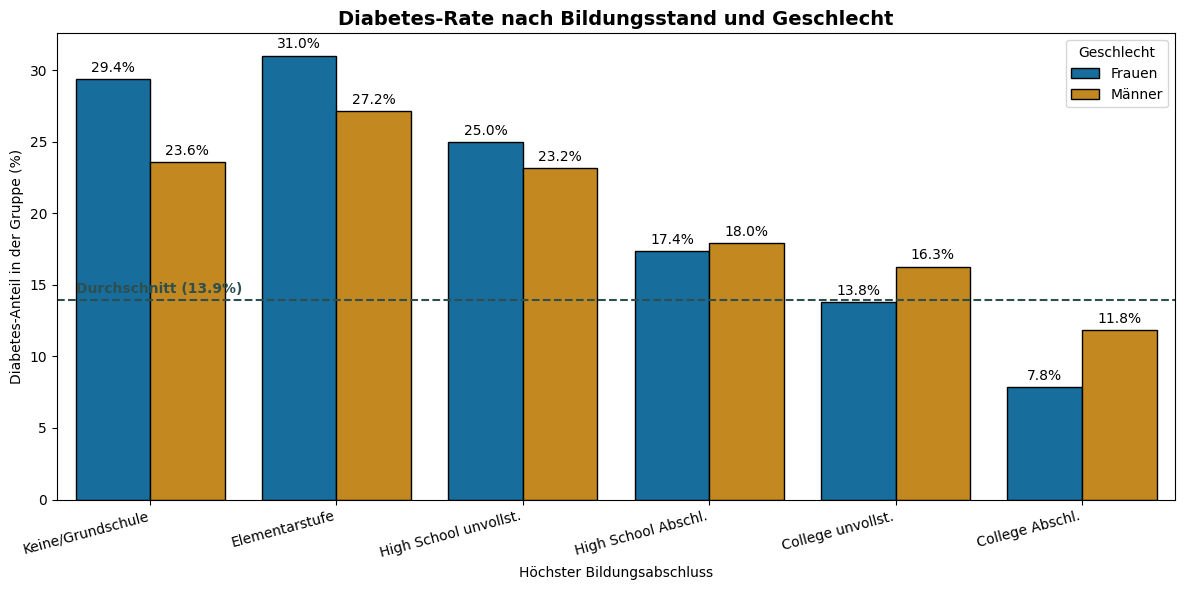

In [35]:
# Grafik: Bildung nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=bildung_rates,
    x="Bildungsstufe_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black"
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Bildungsstand und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Höchster Bildungsabschluss")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper right")

# Prozentzahlen an den Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

3.6.2 Einkommensstufe

In [36]:
# Berechnung: Einkommen nach Geschlecht

# Raten berechnen
einkommen_rates = (df.groupby(["Einkommensstufe", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
einkommen_rates["Geschlecht_Text"] = einkommen_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping für X-Achse
einkommen_mapping = {
    1: "<10k $",
    2: "10k-15k $",
    3: "15k-20k $",
    4: "20k-25k $",
    5: "25k-35k $",
    6: "35k-50k $",
    7: "50k-75k $",
    8: ">=75k $",
}
einkommen_rates["Einkommen_Text"] = einkommen_rates["Einkommensstufe"].map(einkommen_mapping)

# Check
display(einkommen_rates[["Einkommen_Text", "Geschlecht_Text", "Diabetes_Status"]])

,Einkommen_Text,Geschlecht_Text,Diabetes_Status
0,<10k $,Frauen,25.773971
1,<10k $,Männer,21.159328
2,10k-15k $,Frauen,25.936165
3,10k-15k $,Männer,26.718954
4,15k-20k $,Frauen,21.688238
5,15k-20k $,Männer,23.496172
6,20k-25k $,Frauen,18.764141
7,20k-25k $,Männer,22.533479
8,25k-35k $,Frauen,15.699746
9,25k-35k $,Männer,20.033455


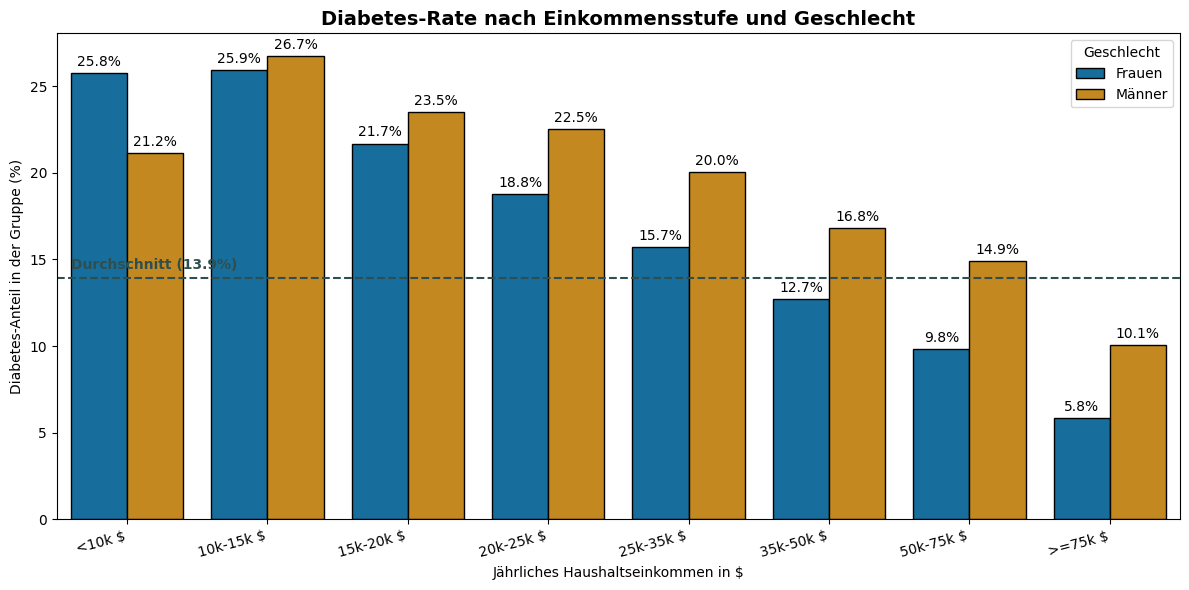

In [37]:
# Grafik: Einkommen nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=einkommen_rates,
    x="Einkommen_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Einkommensstufe und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Jährliches Haushaltseinkommen in $")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper right")

# Gitter im Hintergrund
#plt.grid(axis="y", linestyle="--")

# Prozentzahlen auf die Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

Fazit 3.6 Demografie

Sowohl Bildung als auch Einkommen zeigen ein klares, unbereinigtes Risikogefälle.
Ohne Schulabschluß oder bei einem Einkommen unter 15.000$liegt die Diabetes-Rate bei weit über 20%.
Bei akademischen Abschlüssen sowie in der höchsten Einkommensklasse (ab 75.000 $) bricht die Rate auf unter 10 % ein. 
Männer tragen dabei in fast allen Stufen das geringfügig höhere Risiko.


3.7 Gesundheit<br>
<br>
3.7.1 Allgemeine Gesundheit Balkendiagramm<br>
3.7.2 Körperliche Gesundheit Balkendiagramm<br>
3.7.3 Psychische Gesundheit Balkendiagramm



In [38]:
# Berechnung: Allgemeine Gesundheit nach Geschlecht

# Raten berechnen
allg_gesundheit_rates = (df.groupby(["Allgemeine_Gesundheit", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
allg_gesundheit_rates["Geschlecht_Text"] = allg_gesundheit_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping für X-Achse
allg_gesundheit_mapping = {
    1: "1 - Ausgezeichnet",
    2: "2 - Sehr gut",
    3: "3 - Gut",
    4: "4 - Weniger gut",
    5: "5 - Schlecht"
}
allg_gesundheit_rates["Allgemeine_Gesundheit_Text"] = allg_gesundheit_rates["Allgemeine_Gesundheit"].map(allg_gesundheit_mapping)

# Check
display(allg_gesundheit_rates[["Allgemeine_Gesundheit_Text", "Geschlecht_Text", "Diabetes_Status"]])


# ------------------------------------------------------------------------------
# Berechnung: Körperliche Gesundheit nach Geschlecht

# Hilfsfunktion für die Tage-Kategorisierung
def kategorisiere_tage(tage):
    if tage == 0:
        return "0 Tage"
    elif tage <= 5:
        return "1-5 Tage"
    elif tage <= 14:
        return "6-14 Tage"
    else:
        return "15-30 Tage"

# Kategorisierung anwenden
df["Koerperliche_Beschwerden_Kategorie"] = df["Koerperliche_Gesundheit"].apply(kategorisiere_tage)

# Raten berechnen
koerper_rates = (df.groupby(["Koerperliche_Beschwerden_Kategorie", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
koerper_rates["Geschlecht_Text"] = koerper_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Check
display(koerper_rates[["Koerperliche_Beschwerden_Kategorie", "Geschlecht_Text", "Diabetes_Status"]])


# ------------------------------------------------------------------------------
# Berechnung: Psychische Gesundheit nach Geschlecht

# Kategorisierung anwenden (nutzt dieselbe Hilfsfunktion)
df["Psychische_Beschwerden_Kategorie"] = df["Psychische_Gesundheit"].apply(kategorisiere_tage)

# Raten berechnen
psyche_rates = (df.groupby(["Psychische_Beschwerden_Kategorie", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
psyche_rates["Geschlecht_Text"] = psyche_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Check
display(psyche_rates[["Psychische_Beschwerden_Kategorie", "Geschlecht_Text", "Diabetes_Status"]])

,Allgemeine_Gesundheit_Text,Geschlecht_Text,Diabetes_Status
0,1 - Ausgezeichnet,Frauen,1.756995
1,1 - Ausgezeichnet,Männer,3.499797
2,2 - Sehr gut,Frauen,6.065541
3,2 - Sehr gut,Männer,8.550224
4,3 - Gut,Frauen,16.593348
5,3 - Gut,Männer,19.233238
6,4 - Weniger gut,Frauen,30.190019
7,4 - Weniger gut,Männer,32.143935
8,5 - Schlecht,Frauen,36.479336
9,5 - Schlecht,Männer,39.838836


,Koerperliche_Beschwerden_Kategorie,Geschlecht_Text,Diabetes_Status
0,0 Tage,Frauen,9.143151
1,0 Tage,Männer,11.966064
2,1-5 Tage,Frauen,12.953555
3,1-5 Tage,Männer,15.673208
4,15-30 Tage,Frauen,27.133433
5,15-30 Tage,Männer,30.821862
6,6-14 Tage,Frauen,19.070513
7,6-14 Tage,Männer,21.458333


,Psychische_Beschwerden_Kategorie,Geschlecht_Text,Diabetes_Status
0,0 Tage,Frauen,11.993955
1,0 Tage,Männer,14.758354
2,1-5 Tage,Frauen,11.458488
3,1-5 Tage,Männer,12.584118
4,15-30 Tage,Frauen,20.332414
5,15-30 Tage,Männer,22.827688
6,6-14 Tage,Frauen,15.025297
7,6-14 Tage,Männer,17.400323


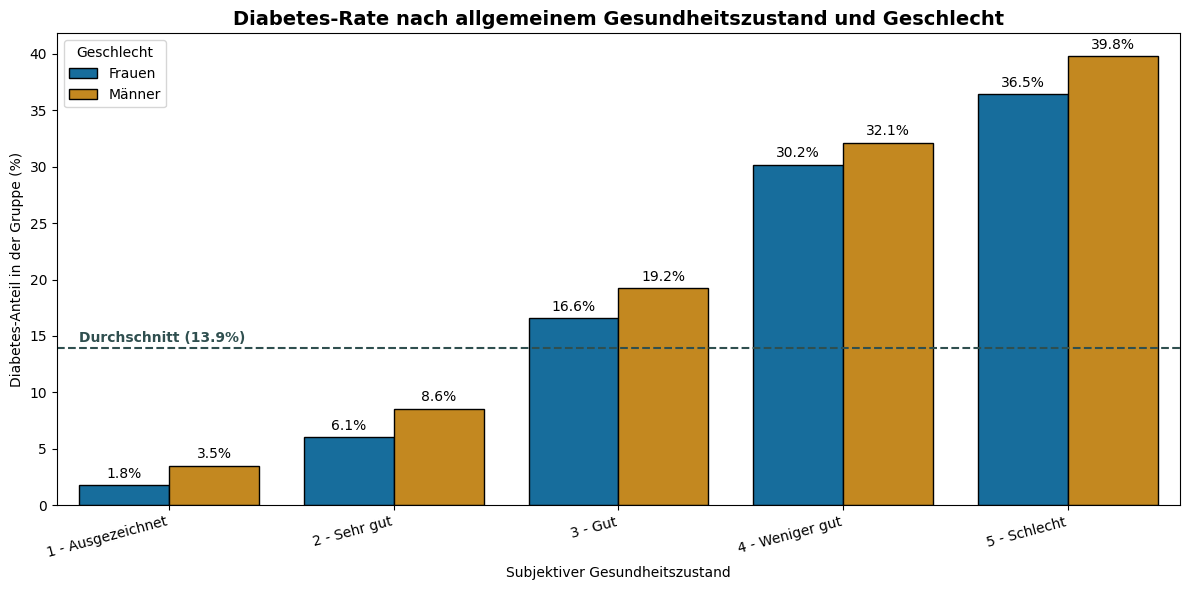

In [39]:
# Grafik: Allgemeine Gesundheit nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=allg_gesundheit_rates,
    x="Allgemeine_Gesundheit_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach allgemeinem Gesundheitszustand und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Subjektiver Gesundheitszustand")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper left")  # Legende nach links verschoben

# Prozentzahlen über Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

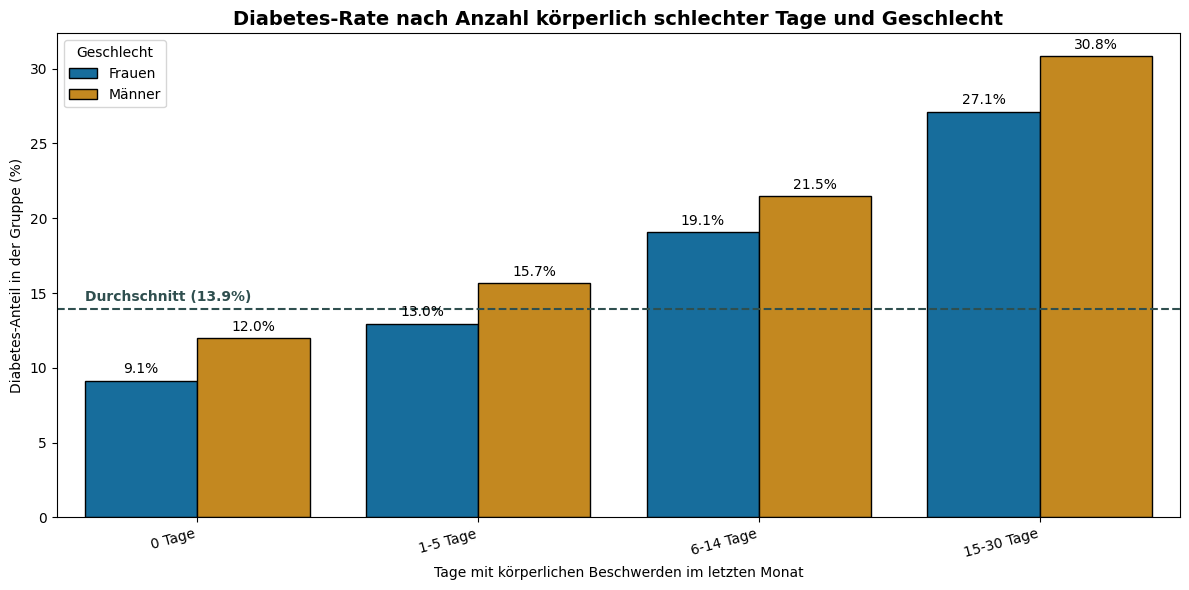

In [40]:
# Grafik: Körperliche Gesundheit nach Geschlecht
plt.figure(figsize=(12, 6))

# Feste Reihenfolge für die X-Achse festlegen
reihenfolge_tage = ["0 Tage", "1-5 Tage", "6-14 Tage", "15-30 Tage"]

ax = sns.barplot(
    data=koerper_rates,
    x="Koerperliche_Beschwerden_Kategorie",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    order=reihenfolge_tage,
    palette="colorblind",
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Anzahl körperlich schlechter Tage und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Tage mit körperlichen Beschwerden im letzten Monat")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper left")  # Legende nach links verschoben

# Prozentzahlen über Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

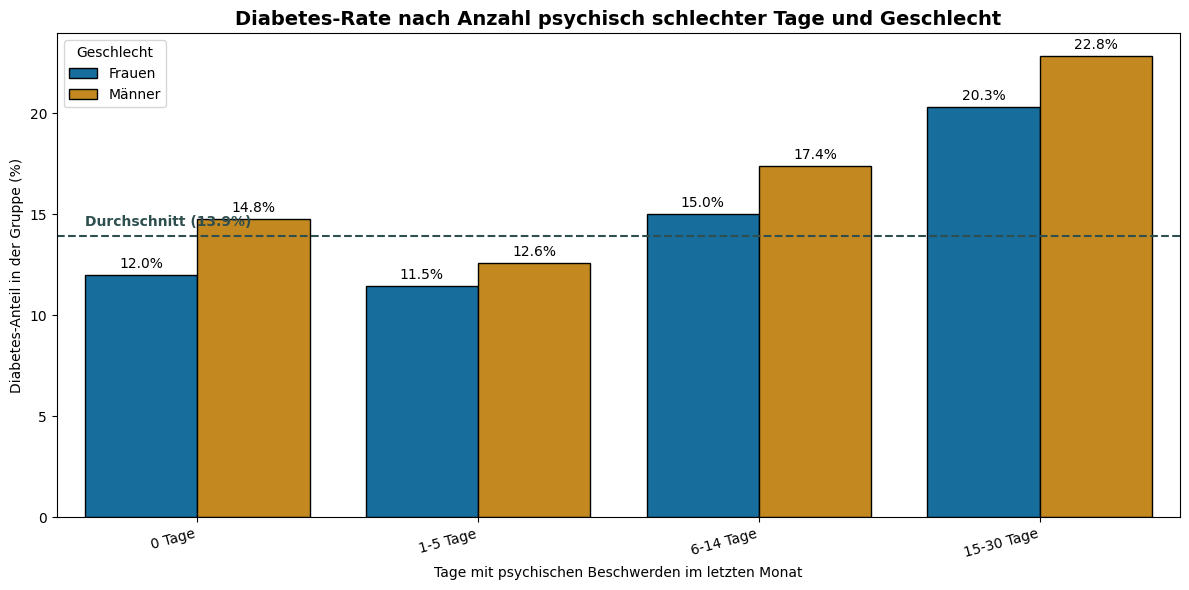

In [41]:
# Grafik: Psychische Gesundheit nach Geschlecht
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=psyche_rates,
    x="Psychische_Beschwerden_Kategorie",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    order=reihenfolge_tage,
    palette="colorblind",
    edgecolor="black",
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(
    -0.4,
    baseline_rate + 0.5,
    f"Durchschnitt ({baseline_rate:.1f}%)",
    color="darkslategray",
    fontweight="bold",
)

# Titel & Achsen
plt.title("Diabetes-Rate nach Anzahl psychisch schlechter Tage und Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Tage mit psychischen Beschwerden im letzten Monat")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

plt.xticks(rotation=15, ha="right")
plt.legend(title="Geschlecht", loc="upper left")  # Legende nach links verschoben

# Prozentzahlen über Balken
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

3.7.4 Allgemeine Gesundheit Liniendiagramm<br>
3.7.5 Körperliche Gesundheit Liniendiagramm<br>
3.7.6 Psychische Gesundheit Liniendiagramm

,Allgemeine_Gesundheit_Text,Geschlecht_Text,Diabetes_Status
0,1 - Ausgezeichnet,Frauen,1.756995
1,1 - Ausgezeichnet,Männer,3.499797
2,2 - Sehr gut,Frauen,6.065541
3,2 - Sehr gut,Männer,8.550224
4,3 - Gut,Frauen,16.593348
5,3 - Gut,Männer,19.233238
6,4 - Weniger gut,Frauen,30.190019
7,4 - Weniger gut,Männer,32.143935
8,5 - Schlecht,Frauen,36.479336
9,5 - Schlecht,Männer,39.838836


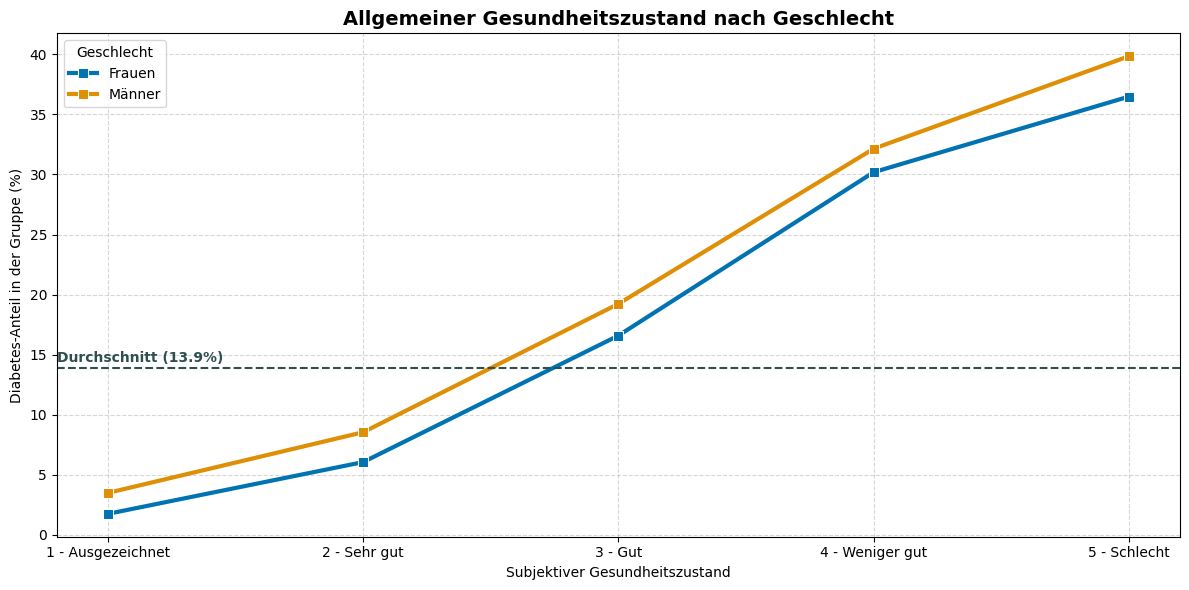

In [42]:
# Allgemeine Gesundheit nach Geschlecht


# Berechnung
allg_gesundheit_rates = (df.groupby(["Allgemeine_Gesundheit", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
allg_gesundheit_rates["Geschlecht_Text"] = allg_gesundheit_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Mapping X-Achse 
allg_gesundheit_mapping = {
    1: "1 - Ausgezeichnet",
    2: "2 - Sehr gut",
    3: "3 - Gut",
    4: "4 - Weniger gut",
    5: "5 - Schlecht"
}
allg_gesundheit_rates["Allgemeine_Gesundheit_Text"] = allg_gesundheit_rates["Allgemeine_Gesundheit"].map(allg_gesundheit_mapping)

# Check 
display(allg_gesundheit_rates[["Allgemeine_Gesundheit_Text", "Geschlecht_Text", "Diabetes_Status"]])


# Grafik
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=allg_gesundheit_rates,
    x="Allgemeine_Gesundheit_Text",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    marker="s",          # Quadratische Datenpunkte auf der Linie
    linewidth=3,         
    markersize=7
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(-0.2, baseline_rate + 0.5, f"Durchschnitt ({baseline_rate:.1f}%)", color="darkslategray", fontweight="bold")

# Titel & Achsen
plt.title("Allgemeiner Gesundheitszustand nach Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Subjektiver Gesundheitszustand")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")

# Gitter und Legende links oben
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Geschlecht", loc="upper left")

plt.tight_layout()
plt.show()

,Koerperliche_Gesundheit,Geschlecht,Diabetes_Status,Geschlecht_Text
0,0,0,9.143151,Frauen
1,0,1,11.966064,Männer
2,1,0,9.372197,Frauen
3,1,1,11.941252,Männer
4,2,0,12.544928,Frauen


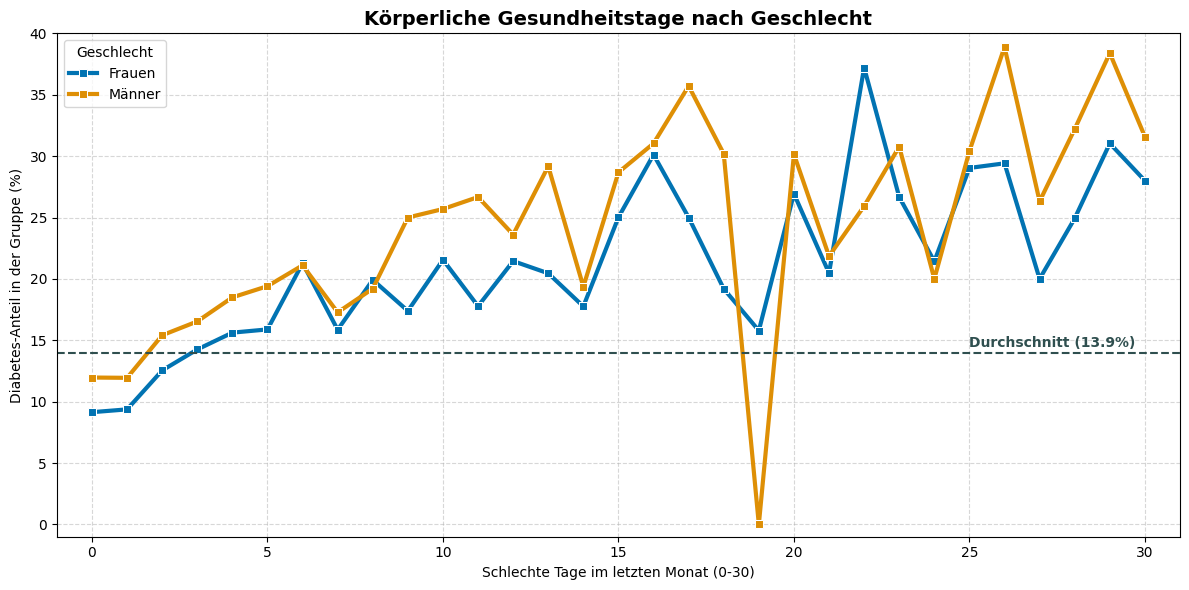

In [98]:
# Körperliche Gesundheit nach Geschlecht

# Berechnung
# für jeden der 0-30 Tage berechnen
koerper_tage_rates = (df.groupby(["Koerperliche_Gesundheit", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
koerper_tage_rates["Geschlecht_Text"] = koerper_tage_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Check der Werte im Notebook
display(koerper_tage_rates.head(5))


# Grafik
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=koerper_tage_rates,
    x="Koerperliche_Gesundheit",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    marker="s",
    linewidth=3,
    markersize=6
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(25, baseline_rate + 0.5, f"Durchschnitt ({baseline_rate:.1f}%)", color="darkslategray", fontweight="bold")

# Titel & Achsen
plt.title("Körperliche Gesundheitstage nach Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Schlechte Tage im letzten Monat (0-30)")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")
plt.xlim(-1, 31)
plt.ylim(-1, 40)

# Gitter und Legende links oben
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Geschlecht", loc="upper left")

plt.tight_layout()
plt.show()

,Psychische_Gesundheit,Geschlecht,Diabetes_Status,Geschlecht_Text
0,0,0,11.993955,Frauen
1,0,1,14.758354,Männer
2,1,0,9.197324,Frauen
3,1,1,10.044360,Männer
4,2,0,10.906686,Frauen


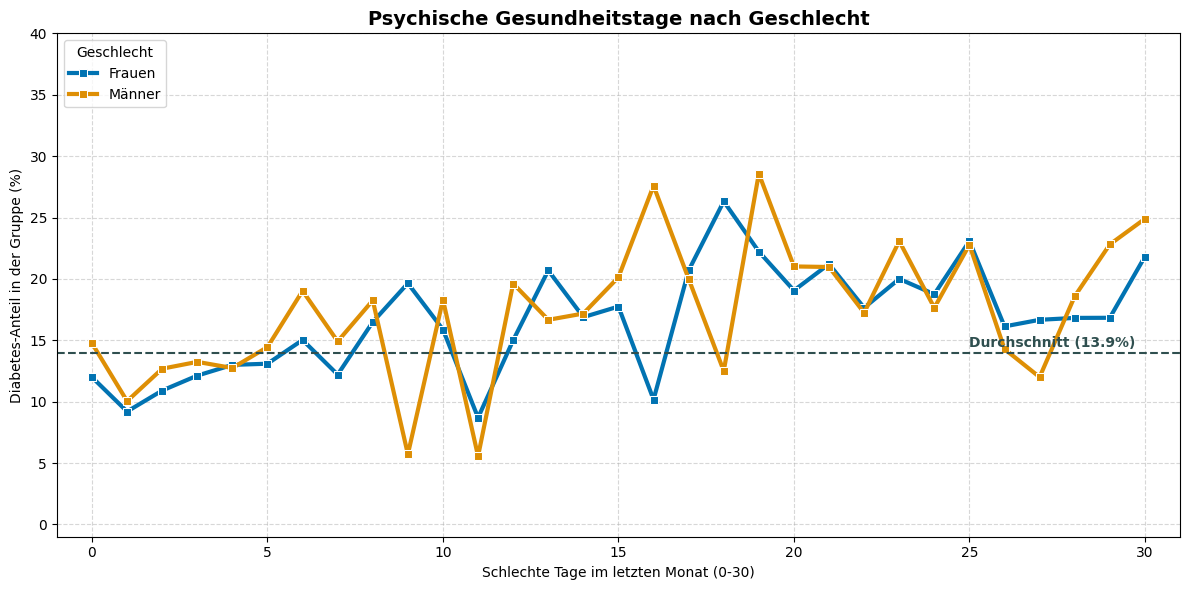

In [105]:
# Psychische Gesundheit nach Geschlecht

# Berechnung
# für jeden der 0-30 Tage berechnen
psyche_tage_rates = (df.groupby(["Psychische_Gesundheit", "Geschlecht"])["Diabetes_Status"].mean() * 100).reset_index()
psyche_tage_rates["Geschlecht_Text"] = psyche_tage_rates["Geschlecht"].map({0: "Frauen", 1: "Männer"})

# Check der Werte im Notebook
display(psyche_tage_rates.head(5))


# Grafik
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=psyche_tage_rates,
    x="Psychische_Gesundheit",
    y="Diabetes_Status",
    hue="Geschlecht_Text",
    palette="colorblind",
    marker="s",
    linewidth=3,
    markersize=6
)

# Durchschnittslinie
plt.axhline(y=baseline_rate, color="darkslategray", linestyle="--")
plt.text(25, baseline_rate + 0.5, f"Durchschnitt ({baseline_rate:.1f}%)", color="darkslategray", fontweight="bold")

# Titel & Achsen
plt.title("Psychische Gesundheitstage nach Geschlecht", fontsize=14, fontweight="bold")
plt.xlabel("Schlechte Tage im letzten Monat (0-30)")
plt.ylabel("Diabetes-Anteil in der Gruppe (%)")
plt.xlim(-1, 31)
plt.ylim(-1, 40)

# Gitter und Legende links oben 
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Geschlecht", loc="upper left")

plt.tight_layout()
plt.show()

Fazit zu Kapitel 3.7 Gesundheit

3.7.1 Allgemeine Gesundheit
 Hier zeigt sich die extremste Risikoänderung im Datensatz. Bei exzellenter subjektiver Gesundheit liegt die Diabetes-Rate unter 3 %, während sie bei schlechtem Zustand auf über 30 % ansteigt. Männer weisen über alle Stufen hinweg ein leicht höheres Niveau auf als Frauen.

3.7.2 Körperliche Gesundheit 
Die Anzahl der monatlichen Beschwerdetage korreliert deutlich mit dem Erkrankungsstatus. Wer dauerhaft körperliche Probleme hat (15 bis 30 Tage), knackt im unbereinigten Vergleich die 24-%-Marke. Der detaillierte Linienverlauf bestätigt einen kontinuierlichen Anstieg mit jedem zusätzlichen Krankheitstag.

3.7.3 Psychische Gesundheit 
Im Vergleich zur körperlichen Belastung verläuft der Trend bei den psychischen Beschwerden auffallend flach. Befragte mit chronischen psychischen Problemen (15 bis 30 Tage) liegen mit ca. 16 % Diabetes-Anteil nur knapp über der Baseline der Beschwerdefreien (ca. 13 %). Psychische Faktoren spielen unbereinigt somit eine untergeordnete Rolle.

<br>
<br>
<br>
3.8 Logistische Regression

In [106]:
# Modell mit den 9 Risikofaktoren definieren
model = smf.logit(
    formula='Diabetes_Status ~ Q("Bluthochdruck") + Q("Cholesterin_hoch") + Q("BMI") + '
            'Q("Allgemeine_Gesundheit") + Q("Geschlecht") + Q("Altersgruppe") + '
            'Q("Bildungsstand") + Q("Einkommensstufe")', 
    data=df
)

results = model.fit()
results.summary()

Optimization terminated successfully.
         Current function value: 0.322393
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        Diabetes_Status   No. Observations:               253680
Model:                          Logit   Df Residuals:                   253671
Method:                           MLE   Df Model:                            8
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.2015
Time:                        14:09:01   Log-Likelihood:                -81785.
converged:                       True   LL-Null:                   -1.0242e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -6.8472      0.058   -117.911      0.000      -6.961      -6.733
Q("Bluthochdruck")             0.7833      0.015     53.453      0.000       0.755       0.812
Q("Cholesterin_hoch")          0.6014      0.013     44.685      0.000       0.575       0.628
Q("BMI")                       0.0630      0.001     71.251      0.000       0.061       0.065
Q("Allgemeine_Gesundheit")     0.5361      0.007     80.770      0.000       0.523       0.549
Q("Geschlecht")                0.2678      0.013     20.596      0.000       0.242       0.293
Q("Altersgruppe")              0.1406      0.003     53.794      0.000       0.136       0.146
Q("Bildungsstand")            -0.0368      0.007     -5.382      0.000      -0.050      -0.023
Q("Einkommensstufe")          -0.0547      0.003    -15.970      0.000      -0.061      -0.048
==============================================================================================
"""

Anmerkung:<br>
R² = 20,15 % - sehr guter Wert<br>
coeff + : erhöhen das Diabetes Risiko -> Bluthochdruck, Cholesterin_hoch, BMI, Allgemeine_Gesundheit, Geschlecht, Altersgruppe<br>
coeff - : verringern das Risiko -> Einkommen und Bildung, d.h. je höher Einkommen und Bildung desto weniger Diabetes


In [107]:
# Achsenabschnitt und Koeffizienten (Slopes) aus der results-Variable

# Achsenabschnitt 
intercept = results.params['Intercept']  # Achsenabschnitt-Grundwert (Zielvariable) -> Diabetes:  Referenzperson bei der alle Variablen den Grundwert 0 annehmen

# Check einzelner Werte (Fehlerfrei korrigiert)
print(f"Achsenabschnitt (Intercept): {intercept:.3f}")
print(f"Anstieg (Slope) Bluthochdruck: {results.params['Q(\"Bluthochdruck\")']:.3f}")
print(f"Anstieg (Slope) BMI: {results.params['Q(\"BMI\")']:.3f}")

Achsenabschnitt (Intercept): -6.847
Anstieg (Slope) Bluthochdruck: 0.783
Anstieg (Slope) BMI: 0.063


In [108]:
# Slopes in Relation mit Odds Ratios (OR)

# Alle Koeffizienten (Slopes) aus den Ergebnissen holen
slopes = results.params

# In Odds Ratios (Chancenverhältnisse) umrechnen
odds_ratios = np.exp(slopes)

# In einer übersichtlichen Tabelle zusammenfassen
df_effekte = pd.DataFrame({
    "Log-Odds (Slope)": slopes,
    "Odds Ratio (OR)": odds_ratios
})

# Den Intercept für den reinen Variablen-Vergleich ausblenden und nach Stärke sortieren -> Grundrisiko/Baseline für Diabeltes, wenn alles Faktoren den Wert 0 haben
df_effekte = df_effekte.drop(index="Intercept", errors="ignore")
df_effekte = df_effekte.sort_values(by="Odds Ratio (OR)", ascending=False)

# Ergebnis gerundet anzeigen
display(df_effekte.round(3))

,Log-Odds (Slope),Odds Ratio (OR)
"Q(""Bluthochdruck"")",0.783,2.189
"Q(""Cholesterin_hoch"")",0.601,1.825
"Q(""Allgemeine_Gesundheit"")",0.536,1.709
"Q(""Geschlecht"")",0.268,1.307
"Q(""Altersgruppe"")",0.141,1.151
"Q(""BMI"")",0.063,1.065
"Q(""Bildungsstand"")",-0.037,0.964
"Q(""Einkommensstufe"")",-0.055,0.947


In [109]:
# Alle Koeffizienten (Slopes) aus den Ergebnissen holen
params = results.params

# Konfidenzintervalle (Unter/Obergrenze) extrahieren
conf = results.conf_int()

# Slopes als neue Spalte in die Konfidenzintervall-Tabelle einfügen
conf['Odds Ratio'] = params

# Spalten umbenennen
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']

# 5. Den Intercept für den reinen Variablen-Vergleich entfernen -> Grundrisiko/Baseline für Diabeltes, wenn alles Faktoren den Wert 0 haben
conf = conf.drop(index="Intercept", errors="ignore")

# Werte in der Tabelle von Log-Odds in Odds Ratios umrechnen
df_effekte_komplett = np.exp(conf)

# Tabelle absteigend sortieren
df_effekte_komplett = df_effekte_komplett.sort_values(by="Odds Ratio", ascending=False)

# Ergebnis gerundet anzeigen
print("Der direkte Vergleich aller Risikofaktoren inkl. Konfidenzintervalle:")
display(df_effekte_komplett.round(3))

Der direkte Vergleich aller Risikofaktoren inkl. Konfidenzintervalle:


,2.5%,97.5%,Odds Ratio
"Q(""Bluthochdruck"")",2.127,2.253,2.189
"Q(""Cholesterin_hoch"")",1.777,1.873,1.825
"Q(""Allgemeine_Gesundheit"")",1.687,1.732,1.709
"Q(""Geschlecht"")",1.274,1.341,1.307
"Q(""Altersgruppe"")",1.145,1.157,1.151
"Q(""BMI"")",1.063,1.067,1.065
"Q(""Bildungsstand"")",0.951,0.977,0.964
"Q(""Einkommensstufe"")",0.940,0.953,0.947


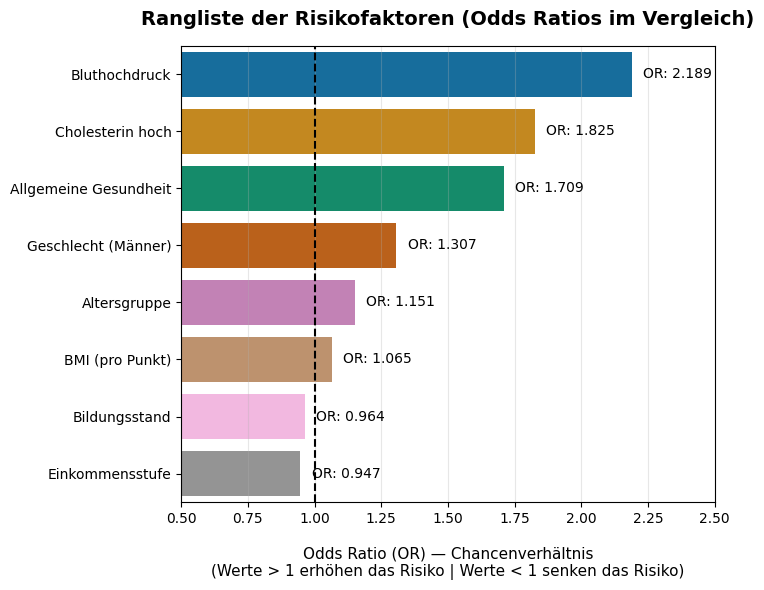

In [110]:
# berechnete Werte in DF laden
data = {
    "Variable": [
        "Bluthochdruck", "Cholesterin hoch", "Allgemeine Gesundheit", 
        "Geschlecht (Männer)", "Altersgruppe", "BMI (pro Punkt)", 
        "Bildungsstand", "Einkommensstufe"
    ],
    "OR": [2.189, 1.825, 1.709, 1.307, 1.151, 1.065, 0.964, 0.947]
}
df_plot = pd.DataFrame(data).sort_values(by="OR", ascending=False)

# Grafik
plt.figure(figsize=(7.5, 6))
ax = sns.barplot(
    x="OR", 
    y="Variable", 
    data=df_plot, 
    palette="colorblind",
    hue="Variable", 
    legend=False
)

# kritische Linie bei 1 einfügen (kein Effekt)
plt.axvline(x=1.0, color="black", linestyle="--", linewidth=1.5)

# Werte als Text an Balken schreiben
for idx, row in df_plot.iterrows():
    ax.annotate(
        f"OR: {row['OR']:.3f}",
        xy=(row['OR'], row['Variable']), # Setzt den Text direkt an das Balkenende
        xytext=(8, 0),                  # Schiebt den Text exakt 8 Bildschirm-Punkte nach rechts
        textcoords="offset points",     # Aktiviert die punktgenaue Verschiebung
        va="center",                    # Zentriert den Text absolut perfekt mittig am Balken
        color="black", 
        #fontweight="bold", 
        fontsize=10
    )

# Titel und Beschriftungen
#plt.title("Rangliste der Risikofaktoren (Odds Ratios im Vergleich)", fontsize=14, fontweight="bold", pad=15)
#plt.xlabel("Odds Ratio (OR) — Chancenverhältnis\n(Werte > 1 erhöhen das Risiko | Werte < 1 senken das Risiko)", fontsize=11)
#plt.ylabel("")

# Beschriftungen
plt.title("Rangliste der Risikofaktoren (Odds Ratios im Vergleich)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel(
    "Odds Ratio (OR) — Chancenverhältnis\n(Werte > 1 erhöhen das Risiko | Werte < 1 senken das Risiko)", 
    fontsize=11, 
    labelpad=15  # Erzeugt Abstand zwischen Diagramm und Beschriftung
)
plt.ylabel("")


# Styling optimieren
plt.xlim(0.5, 2.5)
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Fazit zu Kapitel 3.8 Logistische Regression

Das Modell liefert mit einem Pseudo-R² von 20,15 % eine sehr gute Erklärungsgüte.<br> 
Bluthochdruck (OR: 2,19) und hohes Cholesterin (OR: 1,83) erweisen sich im bereinigten Vergleich als die massivsten Risikofaktoren.<br> 
Ein um einen Punkt höherer BMI steigert das Risiko stetig um 6,5 % (OR: 1,065), was bei einer Erhöhung um 10 Punkte zu einem kumulativen Risikoanstieg von ca. 88 % führt.

Besonders markant ist der sozioökonomische Effekt:<br>
Nach der Bereinigung um Alter und Gewicht kehren sich Bildung und Einkommen in echte Schutzfaktoren um (OR unter 1,0).<br>
Dies beweist, dass ein niedrigerer Status nicht die biologische Ursache für Diabetes ist, sondern statistisch primär mit einem höheren Lebensalter und einem höheren BMI einhergeht. 

Da kein Konfidenzintervall die Neutrallinie von 1,0 schneidet, sind alle Prädaktoren hochgradig signifikant.

<br>
Tabelle: BMI-Punkte<br>

| Zusätzliche BMI-Punkte | Mathematische Formel | Multiplikator (Odds Ratio gesamt) | Risiko-Anstieg in % |
| :--------------------: | :------------------: | :-------------------------------: | :-----------------: |
| **+ 0 Punkte**         | 1,065⁰               | 1,000                             | Baseline (0 %)      |
| **+ 1 Punkt**          | 1,065¹               | 1,065                             | + 6,5 %             |
| **+ 2 Punkte**         | 1,065²               | 1,134                             | + 13,4 %            |
| **+ 3 Punkte**         | 1,065³               | 1,208                             | + 20,8 %            |
| **+ 4 Punkte**         | 1,065⁴               | 1,286                             | + 28,6 %            |
| **+ 5 Punkte**         | 1,065⁵               | 1,370                             | + 37,0 %            |
| **+ 6 Punkte**         | 1,065⁶               | 1,459                             | + 45,9 %            |
| **+ 7 Punkte**         | 1,065⁷               | 1,554                             | + 55,4 %            |
| **+ 8 Punkte**         | 1,065⁸               | 1,655                             | + 65,5 %            |
| **+ 9 Punkte**         | 1,065⁹               | 1,763                             | + 76,3 %            |
| **+ 10 Punkte**        | 1,065¹⁰              | 1,877                             | + 87,7 %            |
| **+ 12 Punkte**        | 1,065¹²              | 2,129                             | + 112,9 % (Risiko verdoppelt!) |
